In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

import opinf

opinf.utils.mpl_config()

In [2]:
# Construct the spatial domain.
L = 1
n = 2**10 - 1
# n = 5
x_all = np.linspace(0, L, n + 2)
x = x_all[1:-1]
dx = x[1] - x[0]

# Construct the temporal domain.
T = 1
K = 10**3 + 1
t_all = np.linspace(0, T, K)
dt = t_all[1] - t_all[0]

# Model parameters
c1, c2 = 1.0, 2.0
# c1, c2 = 1.0, 1.0

# External input functions
def training_input_1(tt):
    return np.ones_like(tt) + np.sin(4 * np.pi * tt) / 4
    # return np.ones_like(tt)

def training_input_2(tt):
    return np.ones_like(tt) + 3.0 * np.sin(4 * np.pi * tt) / 4
    # return np.ones_like(tt) * 2.0

def training_input(tt):
    u1 = training_input_1(tt)
    u2 = training_input_2(tt)
    return np.vstack([u1, u2]).squeeze()

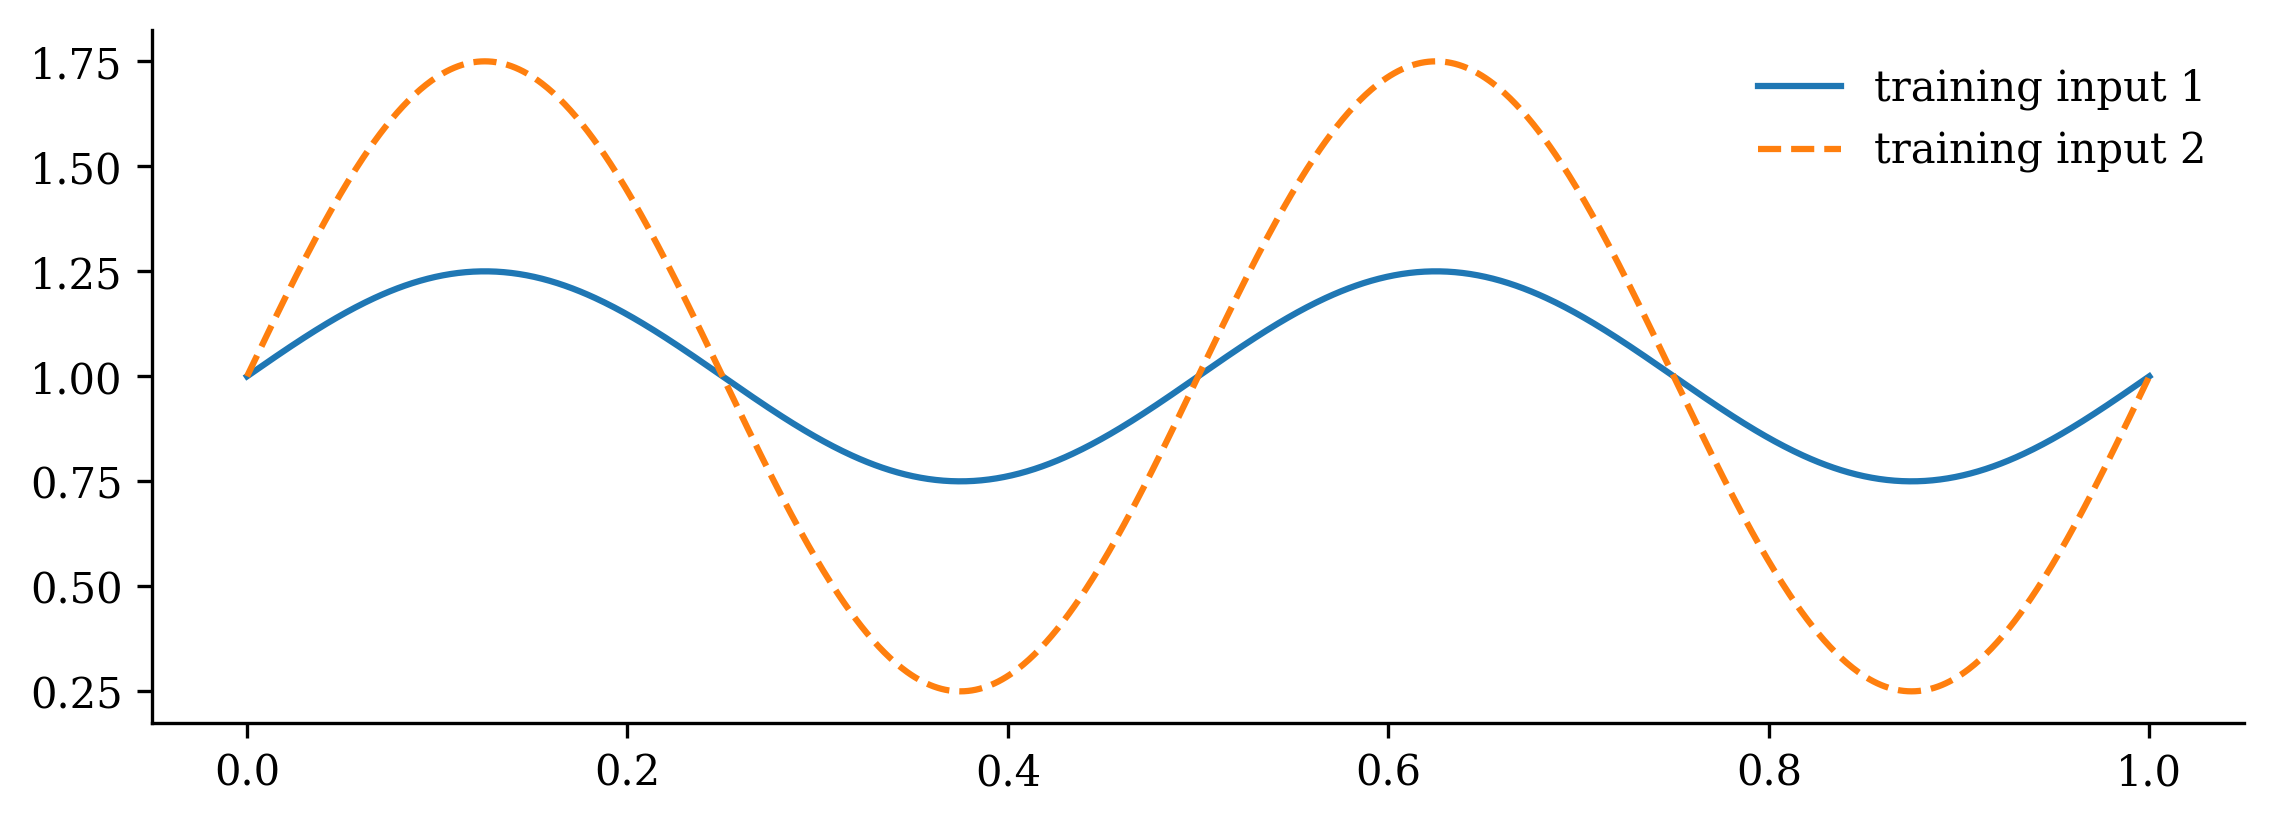

In [3]:
fig, ax = plt.subplots(1, 1)
ax.plot(t_all, training_input(t_all)[0, :], label='training input 1', linestyle="-")
ax.plot(t_all, training_input(t_all)[1, :], label='training input 2', linestyle="--")
ax.legend()
plt.show()

In [4]:
# Construct the full-order state matrix blocks A1, A2.
dx2inv = 1 / dx**2
diags = np.array([1, -2, 1]) * dx2inv
A = sp.sparse.diags(diags, [-1, 0, 1], (n, n))
A = A.todense()
A1 = np.copy(A) * c1
A2 = np.copy(A) * c2

# Construct the full-order coupling matrix blocks E1, E2.
E1 = np.zeros((n, n))
E2 = np.zeros((n, n))
E1[-1, n//2] = dx2inv * c1
E2[0, n//2] = dx2inv * c2

# Assemble the full-order matrix A.
A = np.block([
    [A1, E1],
    [E2, A2],
])

# Construct the full-order input matrix blocks B1, B2.
B = np.zeros_like(x)
B1 = np.copy(B)
B2 = np.copy(B)
B1[0] = dx2inv * c1
B2[-1] = dx2inv * c2

# Assemble the full-order input matrix B.
B = np.block([
    [B1, np.zeros((1, B1.shape[0]))],
    [np.zeros((1, B2.shape[0])), B2],
]).T

# Define the full-order model with an opinf.models class.
fom = opinf.models.ContinuousModel(
    operators=[
        opinf.operators.LinearOperator(A),
        opinf.operators.InputOperator(B),
    ]
)
print(fom)

ContinuousModel
  structure: dq / dt = Aq(t) + Bu(t)
  state_dimension: 2046
  input_dimension: 2
  operators:
    LinearOperator
      state_dimension: 2046
      entries.shape:   (2046, 2046)
    InputOperator
      state_dimension: 2046
      input_dimension: 2
      entries.shape:   (2046, 2)
  solver: None


In [5]:
print(A)
print(B)

[[-2097152.  1048576.        0. ...        0.        0.        0.]
 [ 1048576. -2097152.  1048576. ...        0.        0.        0.]
 [       0.  1048576. -2097152. ...        0.        0.        0.]
 ...
 [       0.        0.        0. ... -4194304.  2097152.        0.]
 [       0.        0.        0. ...  2097152. -4194304.  2097152.]
 [       0.        0.        0. ...        0.  2097152. -4194304.]]
[[1048576.       0.]
 [      0.       0.]
 [      0.       0.]
 ...
 [      0.       0.]
 [      0.       0.]
 [      0. 2097152.]]


0.9966614199246426
1.0
0.9966614199246426
0.9966614199246426
1.0
0.9966614199246426


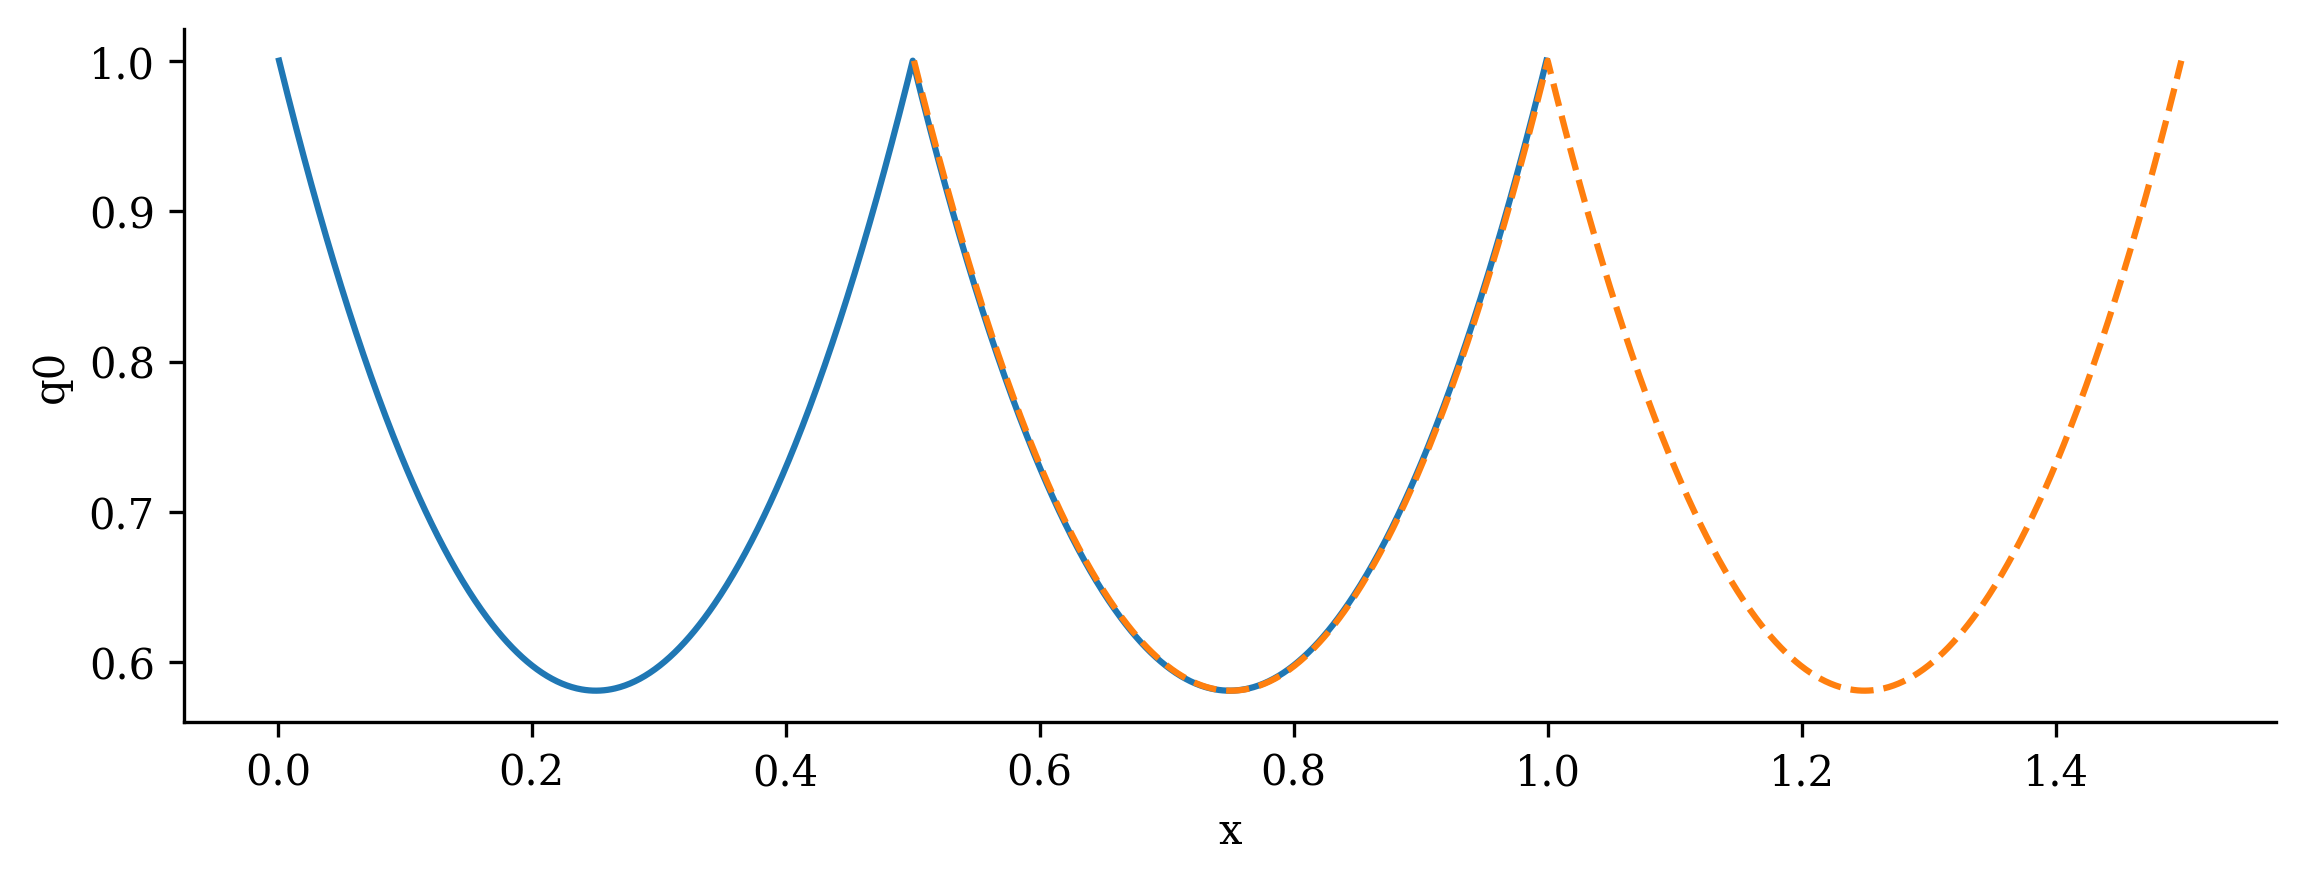

In [6]:
def exp_ic(x, a, b, alpha=1):
    xi, xf = x[0], x[-1]
    t1 = a * np.exp(alpha * (x - xi))
    t2 = b * np.exp(-alpha * (x - xf))
    t3 = (a * (x - xi)/(xf - xi) + b * (x - xf)/(xi - xf)) * np.exp(alpha * (xf - xi))
    return t1 + t2 - t3

u0_0 = training_input_1(0)
uL_0 = training_input_2(0)
uavg = (u0_0 + uL_0) / 2

q0 = np.zeros((2*n,))
q0[:n//2+1] = exp_ic(x[:n//2+1], u0_0, uavg, alpha=2)
q0[n//2:n] = exp_ic(x[n//2:], uavg, uavg, alpha=2)
q0[n:3*n//2+1] = exp_ic(x[:n//2+1], uavg, uavg, alpha=2)
q0[3*n//2:] = exp_ic(x[n//2:], uavg, uL_0, alpha=2)

print(q0[n//2-1])
print(q0[n//2])  # ***
print(q0[n//2+1])
print(q0[3*n//2-1])
print(q0[3*n//2]) # ***
print(q0[3*n//2+1])

fig, ax = plt.subplots()
ax.plot(x, q0[:n], linestyle="-")
ax.plot(x + x[n//2], q0[n:], linestyle="--")
ax.set_xlabel("x")
ax.set_ylabel("q0")
plt.show()

In [7]:
def full_order_solve(time_domain, u):
    """Solve the full-order model with SciPy.
    Here, u is a callable function.
    """
    return fom.predict(q0, time_domain, u, method="BDF")

# Solve the full-order model with the training input.
with opinf.utils.TimedBlock("Full-order solve"):
    Q_all = full_order_solve(t_all, training_input)

# Retain only the first k snapshots/inputs for training the ROM.
k = 200
t = t_all[:k]
Q = Q_all[:, :k]

print(f"\nSpatial domain:\t\t{x.shape=}")
print(f"Spatial step size:\t{dx=:.10f}")
print(f"\nFull time domain:\t{t_all.shape=}")
print(f"Training time domain:\t{t.shape=}")
print(f"Temporal step size:\t{dt=:f}")
print(f"\nFull-order matrix A:\t{A.shape=}")
print(f"Full-order vector B:\t{B.shape=}")
print(f"\nInitial condition:\t{q0.shape=}")
print(f"\nAll FOM solutions:\t{Q_all.shape=}")
print(f"Training snapshots:\t{Q.shape=}")

Full-order solve...done in 4.02 s.

Spatial domain:		x.shape=(1023,)
Spatial step size:	dx=0.0009765625

Full time domain:	t_all.shape=(1001,)
Training time domain:	t.shape=(200,)
Temporal step size:	dt=0.001000

Full-order matrix A:	A.shape=(2046, 2046)
Full-order vector B:	B.shape=(2046, 2)

Initial condition:	q0.shape=(2046,)

All FOM solutions:	Q_all.shape=(2046, 1001)
Training snapshots:	Q.shape=(2046, 200)


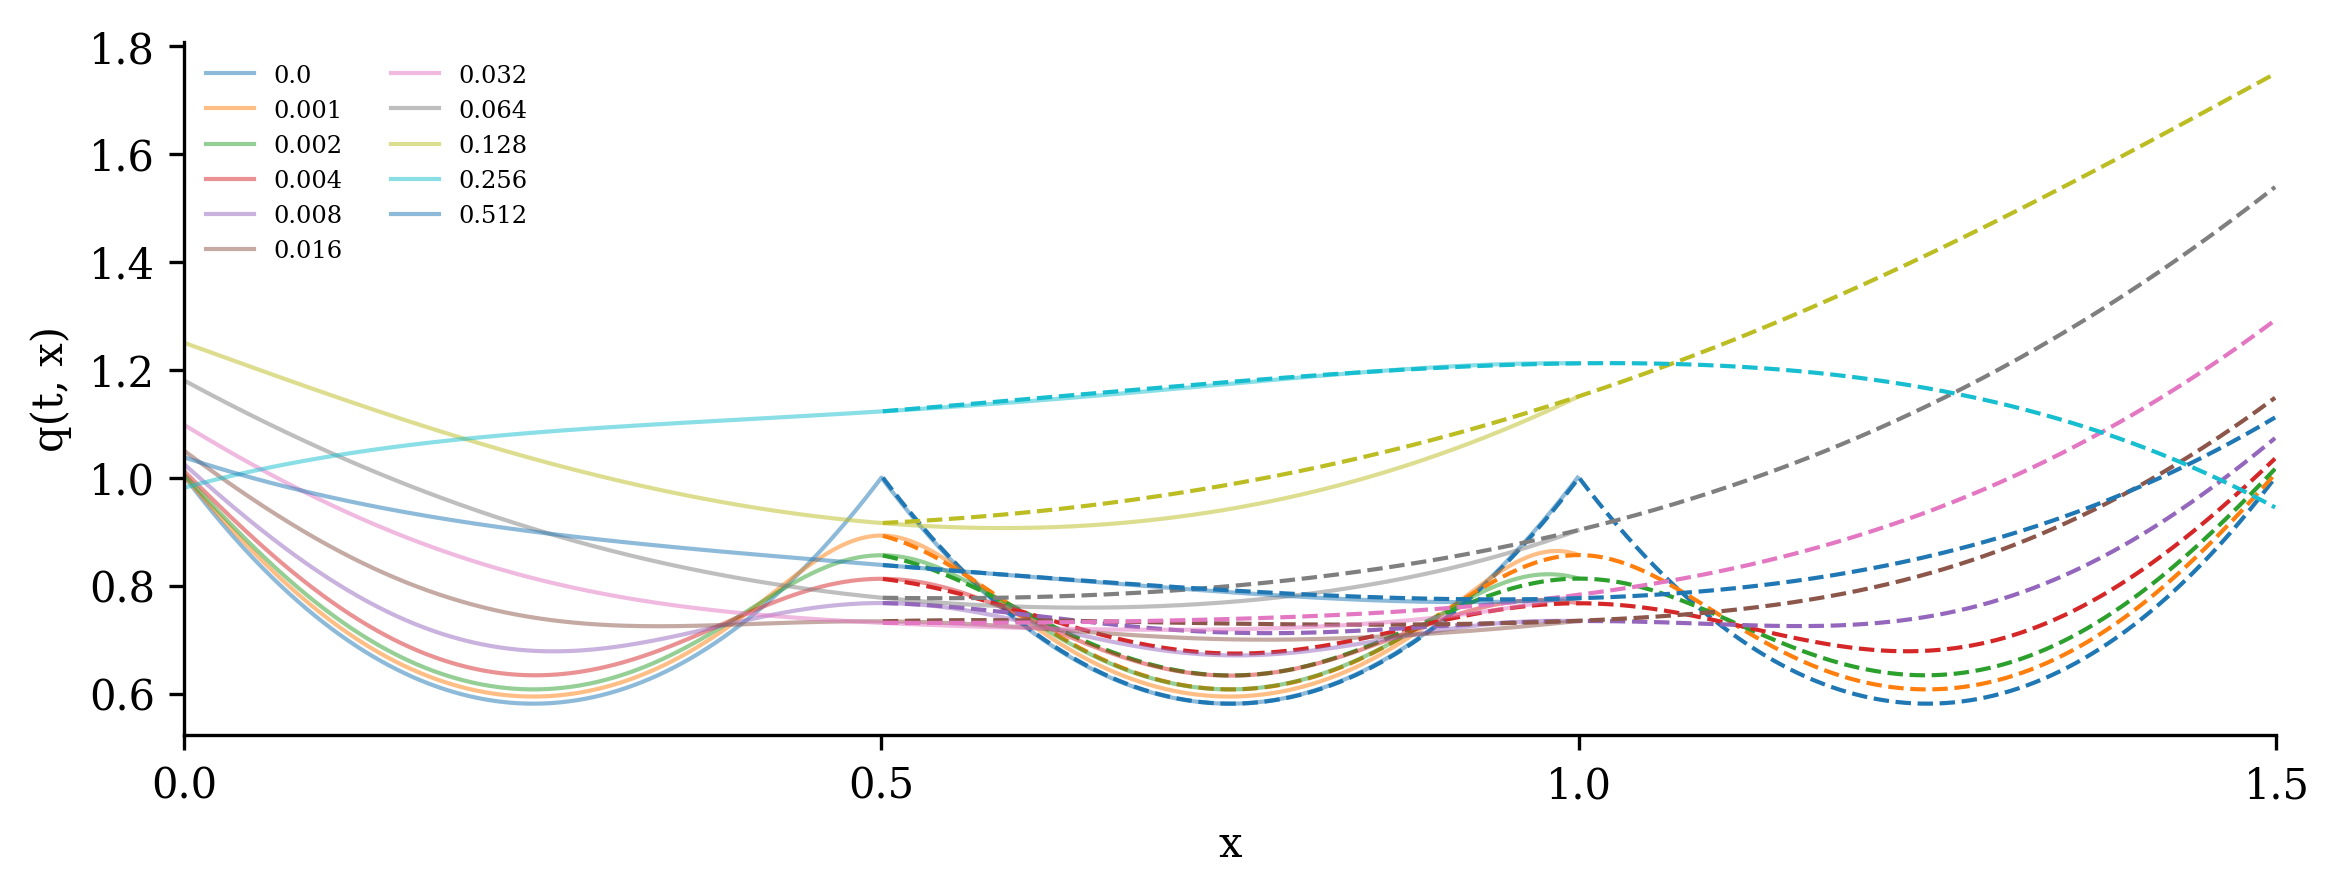

In [8]:
fig, ax = plt.subplots()

for k in [0, 1, 2, 4, 8, 16, 32, 64, 128, 256, 512]:
    y1 = np.concatenate([
        # [training_input(k)[0]],
        Q_all[:n, k],
        # [Q_all[n+n//2, k]],
        ])
    y2 = np.concatenate([
        # [Q_all[n//2, k]],
        Q_all[n:, k],
        # [training_input(k)[1]],
        ])

    l = ax.plot(x, y1, label=t_all[k], linewidth=1, alpha=0.5)
    ax.plot(x + x[n//2], y2, label="", color=l[-1].get_color(), linewidth=1, linestyle="--")

ax.set_xlim([x[0], x[-1] + x[n//2]])

ax.legend(fontsize="xx-small", ncol=2)
ax.set_xticks([0.0, 0.5, 1.0, 1.5])
ax.set_xlabel("x")
ax.set_ylabel("q(t, x)")

plt.show()

### ROM Construction

We now have snapshot data $\Q \in \RR^{n \times k}$, but to learn a model with external inputs, we need training data for the inputs as well as for the snapshots.
Define the vector

$$
\begin{aligned}
    \U = \left[\begin{array}{cccc}
        u_\text{train}(t_0) & u_\text{train}(t_1) & \cdots & u_\text{train}(t_{k-1})
    \end{array}\right]
    \in\RR^{k},
\end{aligned}
$$

which collects the values of the training input function at the same times as the training snapshots.

In [9]:
U = training_input(t)

print(f"Training snapshots:\t{Q.shape=}")
print(f"Training inputs:\t{U.shape=}")

Training snapshots:	Q.shape=(2046, 200)
Training inputs:	U.shape=(2, 200)


We will use a {class}`opinf.basis.PODBasis` to reduce the dimension of the snapshot training data, which approximates the discretized state vector as $\q(t) \approx \Vr\qhat(t)$ for some $\Vr\in\RR^{n\times r}$ with orthonormal columns and $\qhat(t)\in\RR^{r}$, with and $r\ll n$.
Input training data are *not* typically compressed with dimensionality reduction or subjected to other pre-processing routines.
Because the FOM {eq}`eq_inputs_fom` has the linear-time invariant form $\ddt\q(t) = \A\q(t) + \B u(t)$, we seek a ROM with the same structure, i.e.,

$$
\begin{aligned}
    \ddt\qhat(t) = \Ahat\qhat(t) + \Bhat u(t),
    \qquad
    \qhat(0) = \Vr\trp\q_0.
\end{aligned}
$$

Data for the time derivative $\ddt\qhat(t)$ are estimated in this example with sixth-order finite differences using {class}`opinf.ddt.UniformFiniteDifferencer`.
The underlying least-squares problem to determine $\Ahat$ and $\Bhat$ is given by

$$
\begin{aligned}
    \min_{\Ahat,\Bhat}
    \sum_{j=0}^{k-1}\left\|
        \Ahat\qhat_{j} + \Bhat\u_j - \dot{\qhat}_j
    \right\|_{2}^{2},
\end{aligned}
$$

where $\qhat_j = \qhat(t_j)\in\RR^{r}$ and $u_j = u(t_j)\in\RR$ are the state snapshots and input data, respectively, and $\dot{\qhat}_j \approx \ddt\qhat(t)|_{t=t_j}\in\RR^{r}$ are the estimated time derivatives.

:::{dropdown} Why Use the Same Structure?

An OpInf ROM should have the same structure as an intrusive Galerkin ROM.
The Galerkin ROM for {eq}`eq_inputs_fom` is derived by substituting in the approximation $\q(t)\approx\Vr\qhat(t)$, yielding

$$
\begin{aligned}
    \ddt\Vr\qhat(t) = \A\Vr\qhat(t) + \B u(t),
    \qquad
    \Vr\qhat(0) = \q_0.
\end{aligned}
$$

Next, left multiply by $\Vr\trp$ and use the fact that $\Vr\trp\Vr = \I$ to get the following:

$$
\begin{aligned}
    \ddt\qhat(t) = \tilde{\A}\qhat(t) + \tilde{\B}u(t),
    \qquad
    \qhat(0) = \Vr\trp\q_0,
\end{aligned}
$$

where $\tilde{\A} = \Vr\trp\A\Vr \in \RR^{r\times r}$ and $\tilde{\B} = \Vr\trp\B\in\RR^{r}$.
Note that this ROM has the same input function $u(t)$ as the FOM.
:::

Training input data are passed to {meth}`opinf.roms.ROM.fit()` as the `inputs` argument.

In [10]:
rom = opinf.ROM(
    # basis=opinf.basis.PODBasis(residual_energy=1e-6),
    basis=opinf.basis.PODBasis(residual_energy=1e-8),
    ddt_estimator=opinf.ddt.UniformFiniteDifferencer(t, "ord6"),
    model=opinf.models.ContinuousModel("AB"),
)

with opinf.utils.TimedBlock("Fitting OpInf ROM"):
    rom.fit(Q, inputs=U)

with opinf.utils.TimedBlock("Reduced-order solve"):
    Q_ROM = rom.predict(q0, t_all, input_func=training_input, method="BDF")

Fitting OpInf ROM...done in 0.17 s.
Reduced-order solve...done in 0.05 s.


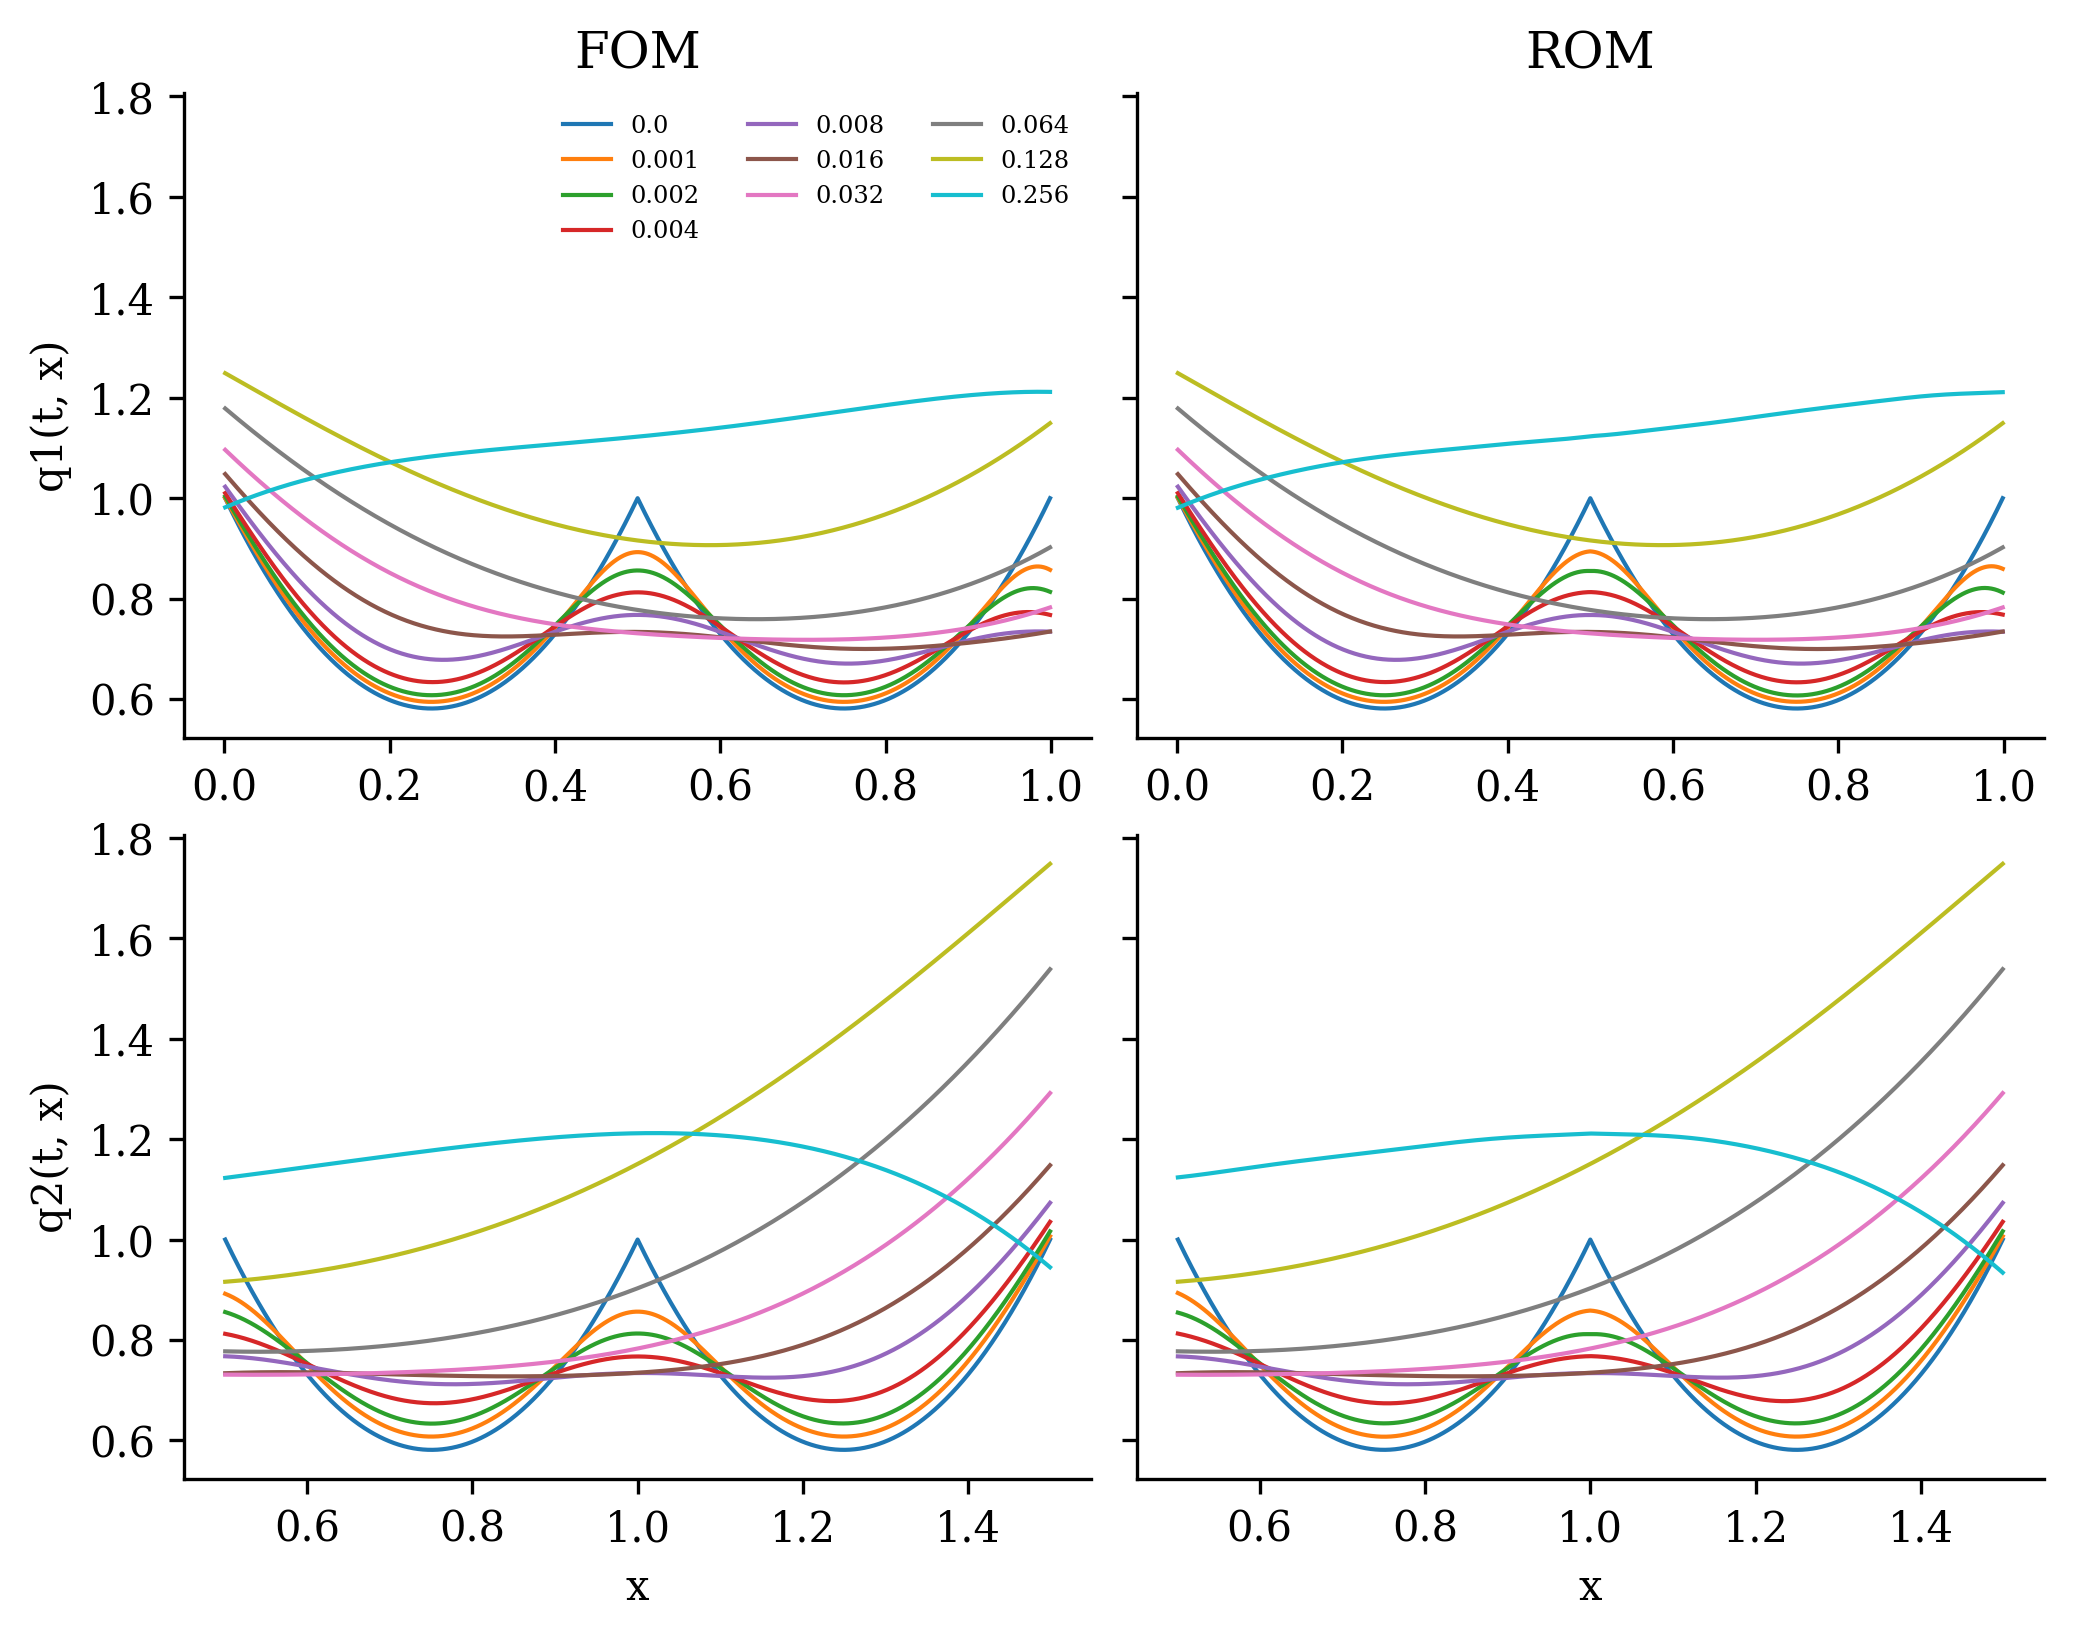

In [11]:
fig, ax = plt.subplots(2, 2, sharex="row", sharey=True, figsize=(8, 6))

for k in [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]:
    y1 = np.concatenate([
        # [training_input(k)[0]],
        Q_all[:n, k],
        # [Q_all[n+n//2, k]],
        ])
    y1rom = np.concatenate([
        # [training_input(k)[0]],
        Q_ROM[:n, k],
        # [Q_all[n+n//2, k]],
        ])
    y2 = np.concatenate([
        # [Q_all[n//2, k]],
        Q_all[n:, k],
        # [training_input(k)[1]],
        ])
    y2rom = np.concatenate([
        # [Q_all[n//2, k]],
        Q_ROM[n:, k],
        # [training_input(k)[1]],
        ])

    l = ax[0, 0].plot(x, y1, label=t_all[k], linewidth=1)
    ax[0, 1].plot(x, y1rom, label=t_all[k], linewidth=1, color=l[-1].get_color())

    l = ax[1, 0].plot(x + x[n//2], y2, label=t_all[k], linewidth=1)
    ax[1, 1].plot(x + x[n//2], y2rom, label=t_all[k], linewidth=1, color=l[-1].get_color())

ax[0, 0].set_title("FOM")
ax[0, 1].set_title("ROM")

ax[1, 0].set_xlabel("x")
ax[1, 1].set_xlabel("x")

ax[0, 0].set_ylabel("q1(t, x)")
ax[1, 0].set_ylabel("q2(t, x)")

ax[0, 0].legend(fontsize="xx-small", ncol=3)

fig.subplots_adjust(wspace=0.05, hspace=0.15)

plt.show()

For a closer look at the difference between the FOM and ROM solutions, we compute the relative $\ell_2$-norm error of the ROM solution as a function of time using {func}`opinf.post.lp_error()` and the relative Forbenius-norm error using {func}`opinf.post.frobenius_error()`.

In [12]:
def plot_errors_over_time(
    Ztrue, basis, Z1, label1, Z2=None, label2=None, cutoff=None
):
    """Plot normalized absolute projection error and ROM error(s)
    as a function of time.
    """
    _, ax = plt.subplots(1, 1)

    projection_err = opinf.post.lp_error(Ztrue, basis.project(Ztrue))[1]
    ax.semilogy(t_all, projection_err, "C3-", lw=1, label="Projection Error")

    relative_error = opinf.post.lp_error(Ztrue, Z1)[1]
    ax.semilogy(t_all, relative_error, "C0--", lw=1, label=label1)

    if Z2 is not None:
        relative_error = opinf.post.lp_error(Ztrue, Z2)[1]
        ax.semilogy(t_all, relative_error, "C5-.", lw=1, label=label2)

    if cutoff is not None:
        ax.axvline(cutoff, color="gray", linewidth=1, linestyle="--")
        ymin = projection_err.min() / 4
        ax.text(cutoff - 10 * dt, ymin, "training", ha="right", color="gray")
        ax.text(cutoff + 10 * dt, ymin, "prediction", ha="left", color="gray")
        ax.set_ylim(bottom=ymin / 2)

    ax.set_xlim(t_all[0], t_all[-1])
    ax.set_xlabel(r"$t$")
    ax.set_ylabel("Relative error")
    ax.legend(loc="lower right")
    plt.show()

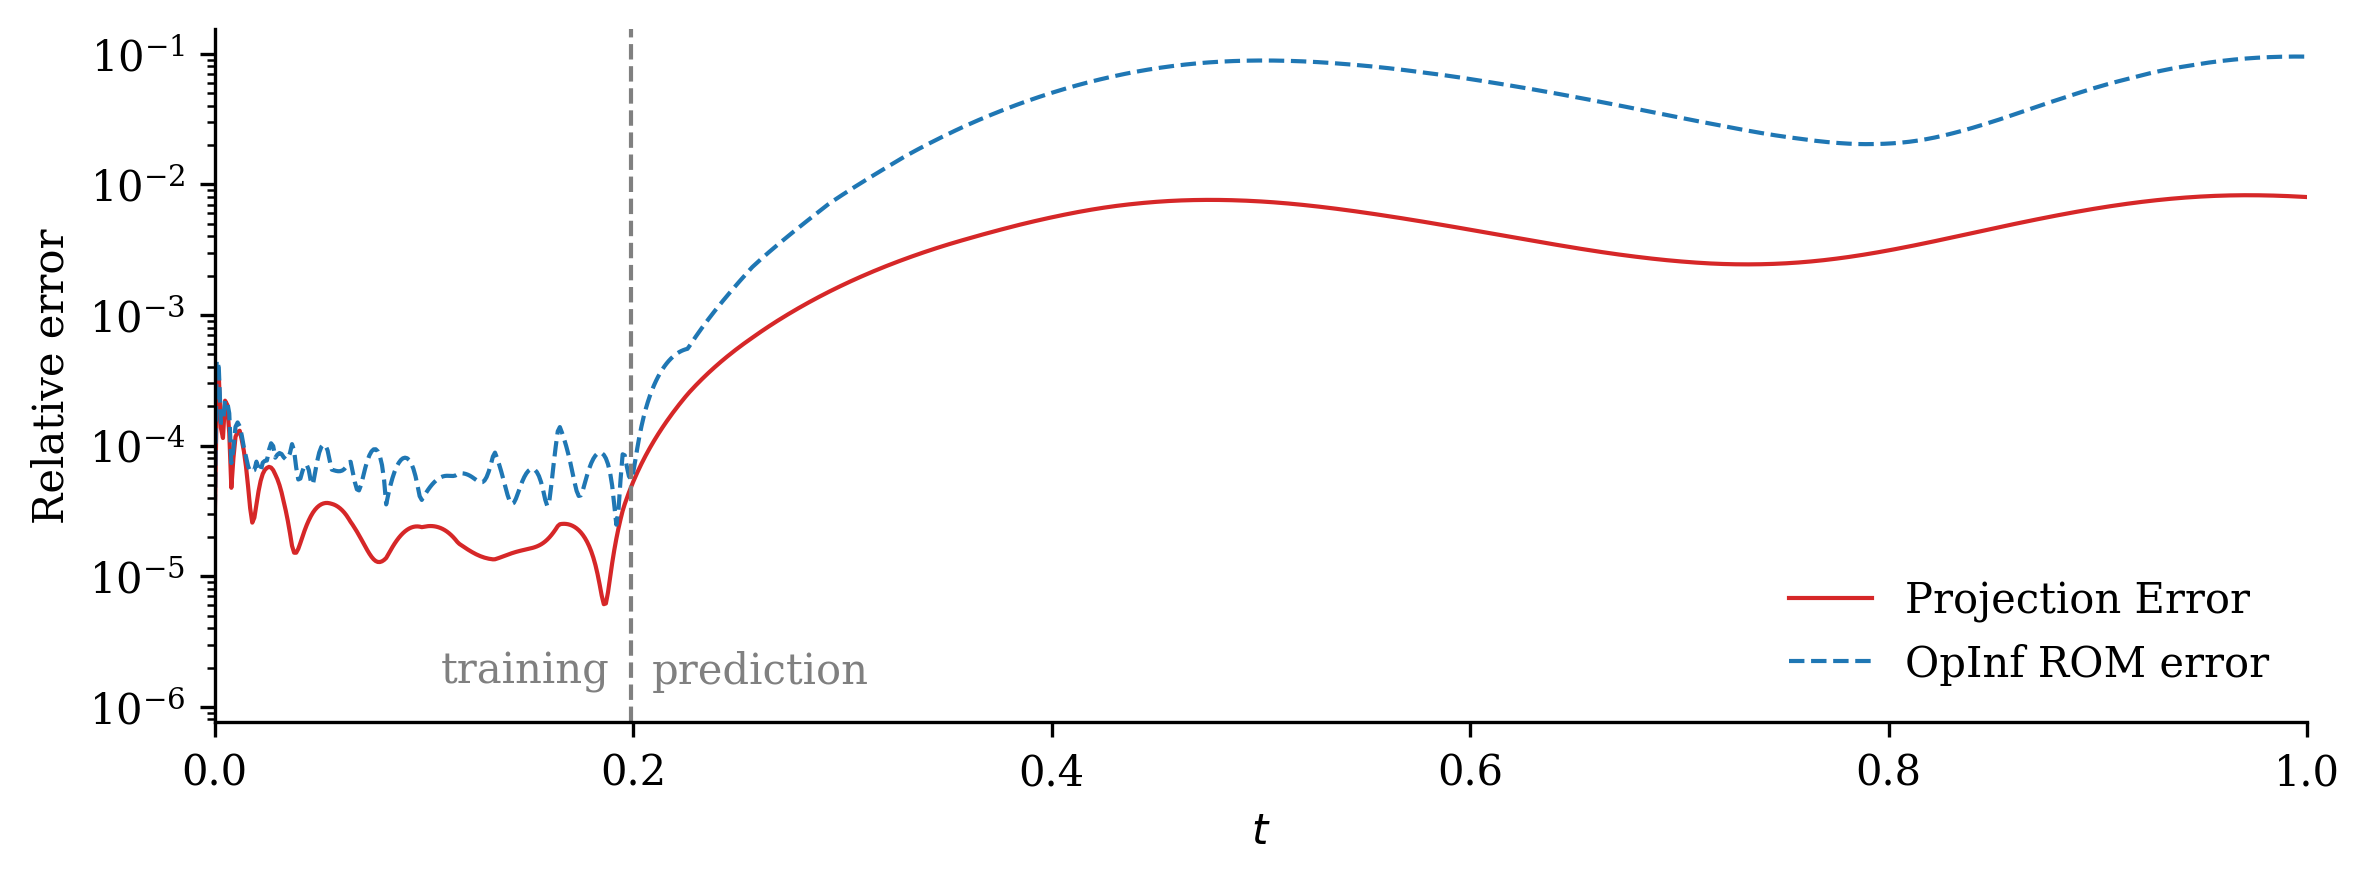

In [13]:
plot_errors_over_time(Q_all, rom.basis, Q_ROM, "OpInf ROM error", cutoff=t[-1])

In [14]:
error_opinf = opinf.post.frobenius_error(Q_all, Q_ROM)[1]
print(f"OpInf ROM error:\t{error_opinf:.4e}")

OpInf ROM error:	4.3399e-02


### Generalization to New Inputs

The previous experiment uses a single choice of $u(t)$ for the training and for the prediction in time.
Now, we define a new choice of input function $u(t)$,

$$
\begin{aligned}
    u_\text{test}(t)
    = 1 + t(1 - t),
\end{aligned}
$$

and evaluate the FOM and ROM for this new input.

In [24]:
def test_input_1(t):
    return 1 + t * (1 - t)

def test_input_2(t):
    return 1 + t * (1 - t)

def test_input(tt):
    u1 = test_input_1(tt)
    u2 = test_input_2(tt)
    return np.vstack([u1, u2]).squeeze()

In [25]:
with opinf.utils.TimedBlock("Full-order solve"):
    Qtest_FOM = full_order_solve(t_all, test_input)

with opinf.utils.TimedBlock("Reduced-order solve (OpInf)"):
    Qtest_ROM = rom.predict(q0, t_all, test_input, method="BDF")

# with opinf.utils.TimedBlock("Reduced-order solve (intrusive)"):
#     Qtest_ROM_intrusive = rom_intrusive.predict(
#         q0, t_all, test_input, method="BDF"
#     )

Full-order solve...done in 4.36 s.
Reduced-order solve (OpInf)...done in 0.07 s.


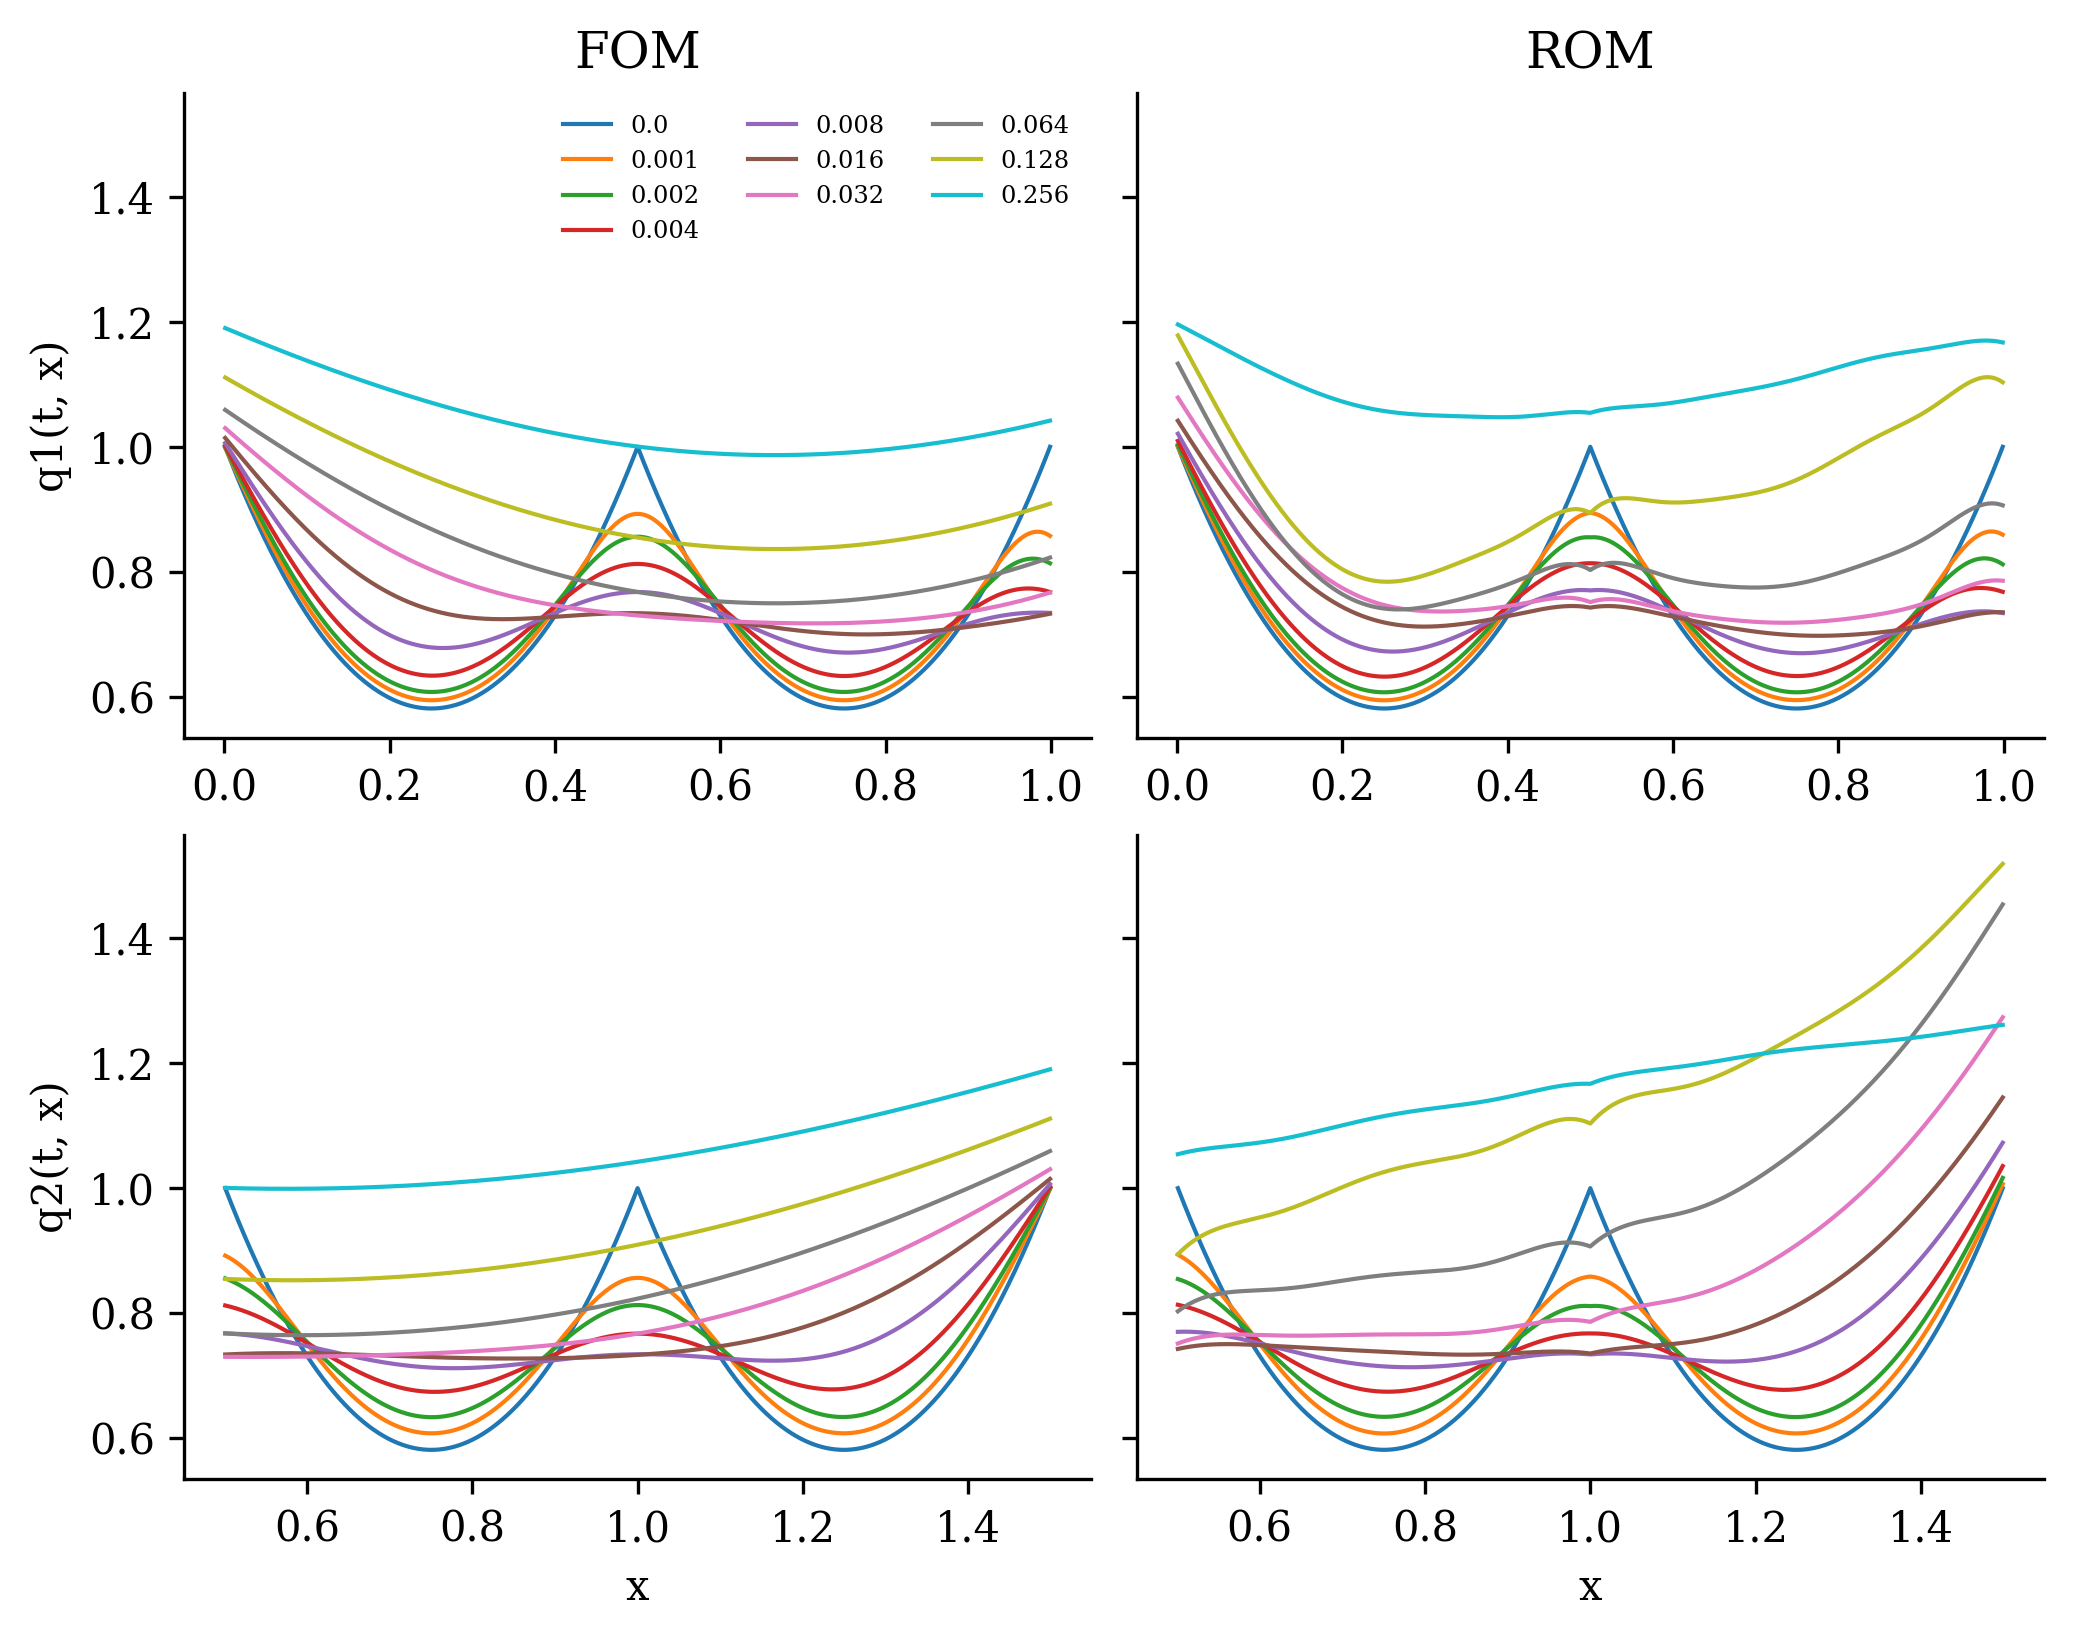

In [26]:
fig, ax = plt.subplots(2, 2, sharex="row", sharey=True, figsize=(8, 6))

for k in [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]:
    y1 = np.concatenate([
        # [training_input(k)[0]],
        Qtest_FOM[:n, k],
        # [Qtest_FOM[n+n//2, k]],
        ])
    y1rom = np.concatenate([
        # [training_input(k)[0]],
        Qtest_ROM[:n, k],
        # [Qtest_FOM[n+n//2, k]],
        ])
    y2 = np.concatenate([
        # [Qtest_FOM[n//2, k]],
        Qtest_FOM[n:, k],
        # [training_input(k)[1]],
        ])
    y2rom = np.concatenate([
        # [Qtest_FOM[n//2, k]],
        Qtest_ROM[n:, k],
        # [training_input(k)[1]],
        ])

    l = ax[0, 0].plot(x, y1, label=t_all[k], linewidth=1)
    ax[0, 1].plot(x, y1rom, label=t_all[k], linewidth=1, color=l[-1].get_color())

    l = ax[1, 0].plot(x + x[n//2], y2, label=t_all[k], linewidth=1)
    ax[1, 1].plot(x + x[n//2], y2rom, label=t_all[k], linewidth=1, color=l[-1].get_color())

ax[0, 0].set_title("FOM")
ax[0, 1].set_title("ROM")

ax[1, 0].set_xlabel("x")
ax[1, 1].set_xlabel("x")

ax[0, 0].set_ylabel("q1(t, x)")
ax[1, 0].set_ylabel("q2(t, x)")

ax[0, 0].legend(fontsize="xx-small", ncol=3)

fig.subplots_adjust(wspace=0.05, hspace=0.15)

plt.show()

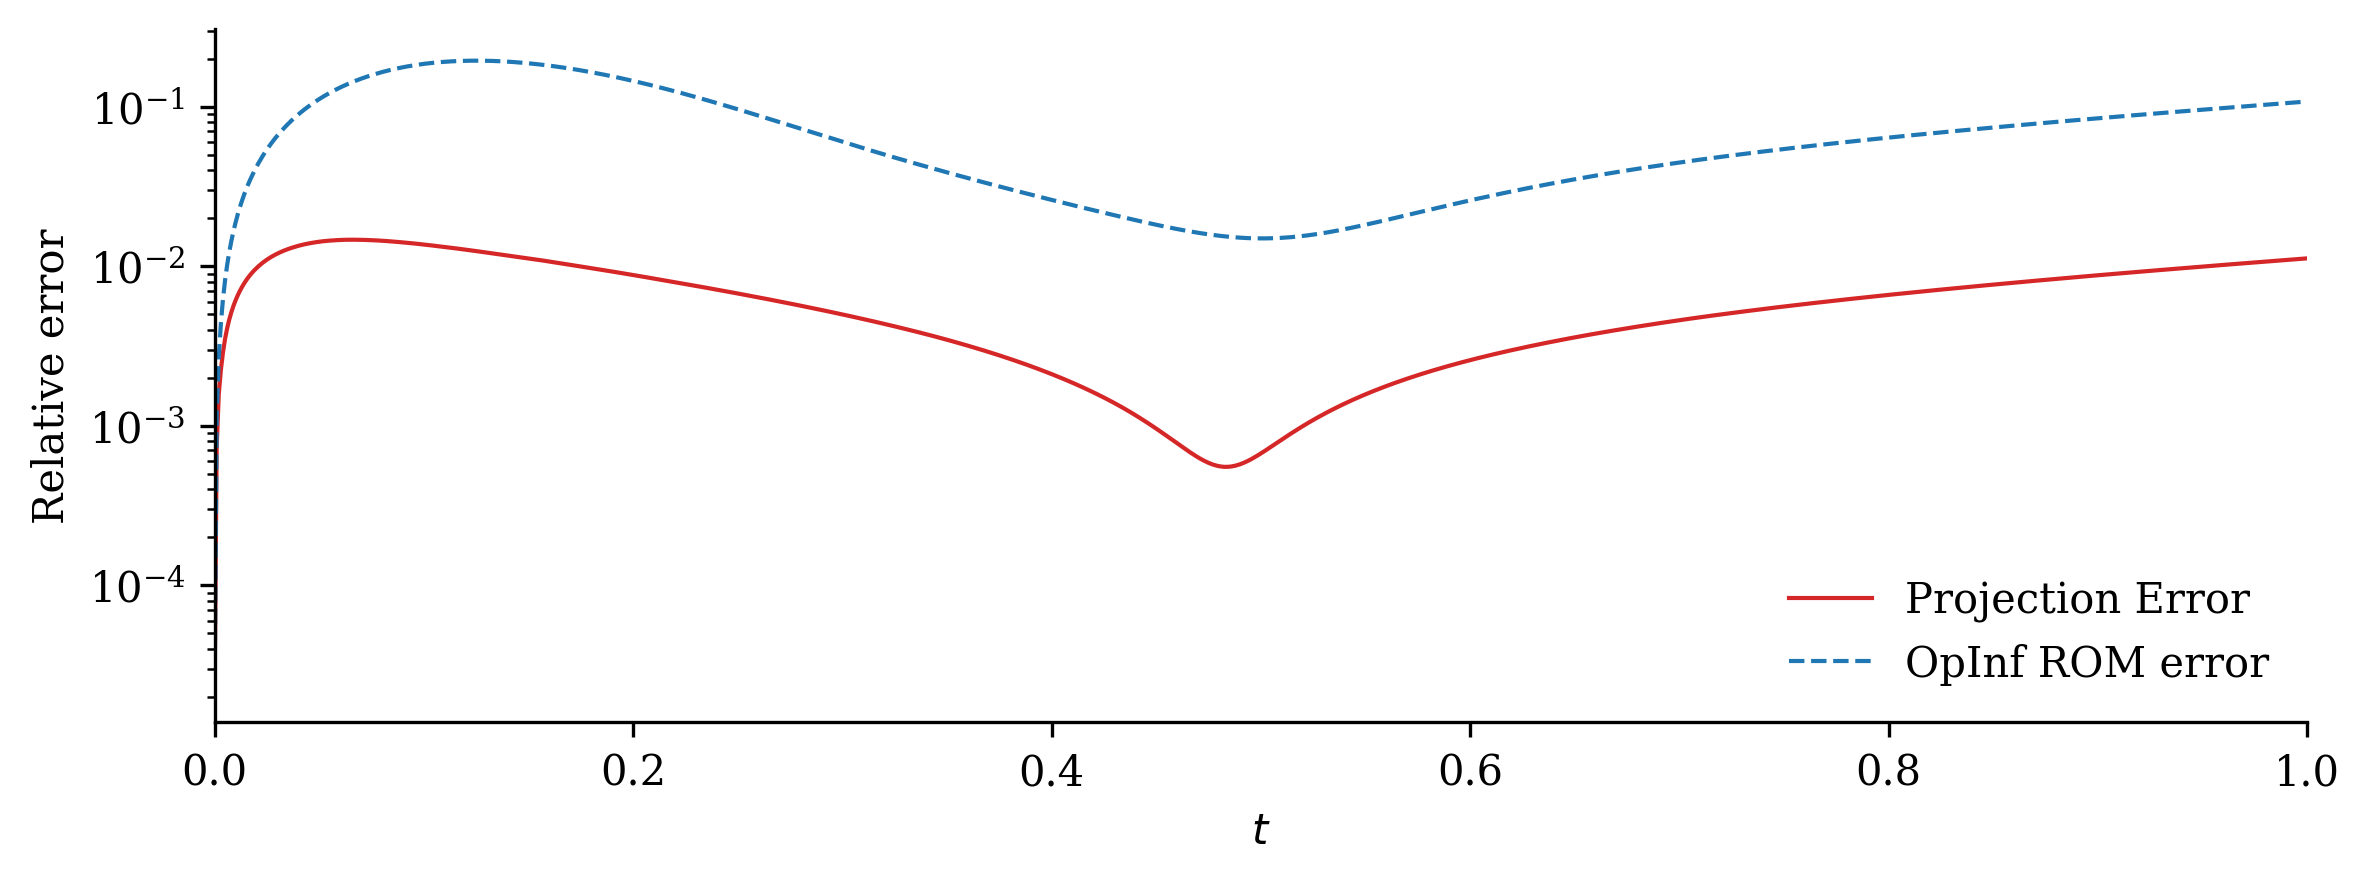

In [27]:
plot_errors_over_time(
    Qtest_FOM,
    rom.basis,
    Qtest_ROM,
    "OpInf ROM error",
    # Qtest_ROM_intrusive,
    # "Intrusive ROM error",
)

Both ROMs perform well with a new input function, but the intrusive ROM performs slightly better than the OpInf ROM.
This is typical; intrusive ROMs are often more robust and generalizable than standard OpInf ROMs, but OpInf ROMs tend to reproduce training data better than intrusive ROMs.

## Multiple Training Trajectories

If data corresponding to several choices of the input function $u(t)$ are available for training, we collect a list of snapshot matrices and a list of corresponding inputs to pass to `fit()`.

### Training Data Generation

Below, we solve the PDE using the three input functions for training data:

$$
\begin{aligned}
    &u_\text{train}^{(1)}(t) = e^{-t},
    &&&
    &u_\text{train}^{(2)}(t) = 1 + \frac{1}{2}t^2,
    &&&
    &u_\text{train}^{(3)}(t) = 1 - \frac{1}{2}\sin(\pi t).
\end{aligned}
$$

The following input functions are used for testing.

$$
\begin{aligned}
    &u_\text{test}^{(1)}(t) = 1 - \frac{1}{2}\sin(3\pi t),
    &&&
    &u_\text{test}^{(2)}(t) = 1 + 25 (t (t - 1))^3,
    &&&
    &u_\text{test}^{(3)}(t) = 1 + e^{-2t}\sin(\pi t).
\end{aligned}
$$

In [28]:
training_inputs = [
    lambda t: np.vstack([
        np.exp(-t),
        np.exp(-t),
        ]).squeeze(),
    lambda t: np.vstack([
        1 + t**2 / 2,
        1 + t**2 / 2,
        ]).squeeze(),
    lambda t: np.vstack([
        1 - np.sin(np.pi * t) / 2,
        1 - np.sin(np.pi * t) / 2,
        ]).squeeze(),
]

testing_inputs = [
    lambda t: np.vstack([
        1 - np.sin(3 * np.pi * t) / 3,
        1 - np.sin(3 * np.pi * t) / 3,
        ]).squeeze(),
    lambda t: np.vstack([
        1 + 25 * (t * (t - 1)) ** 3,
        1 + 25 * (t * (t - 1)) ** 3,
        ]).squeeze(),
    lambda t: np.vstack([
        1 + np.exp(-2 * t) * np.sin(np.pi * t),
        1 + np.exp(-2 * t) * np.sin(np.pi * t),
        ]).squeeze(),
]

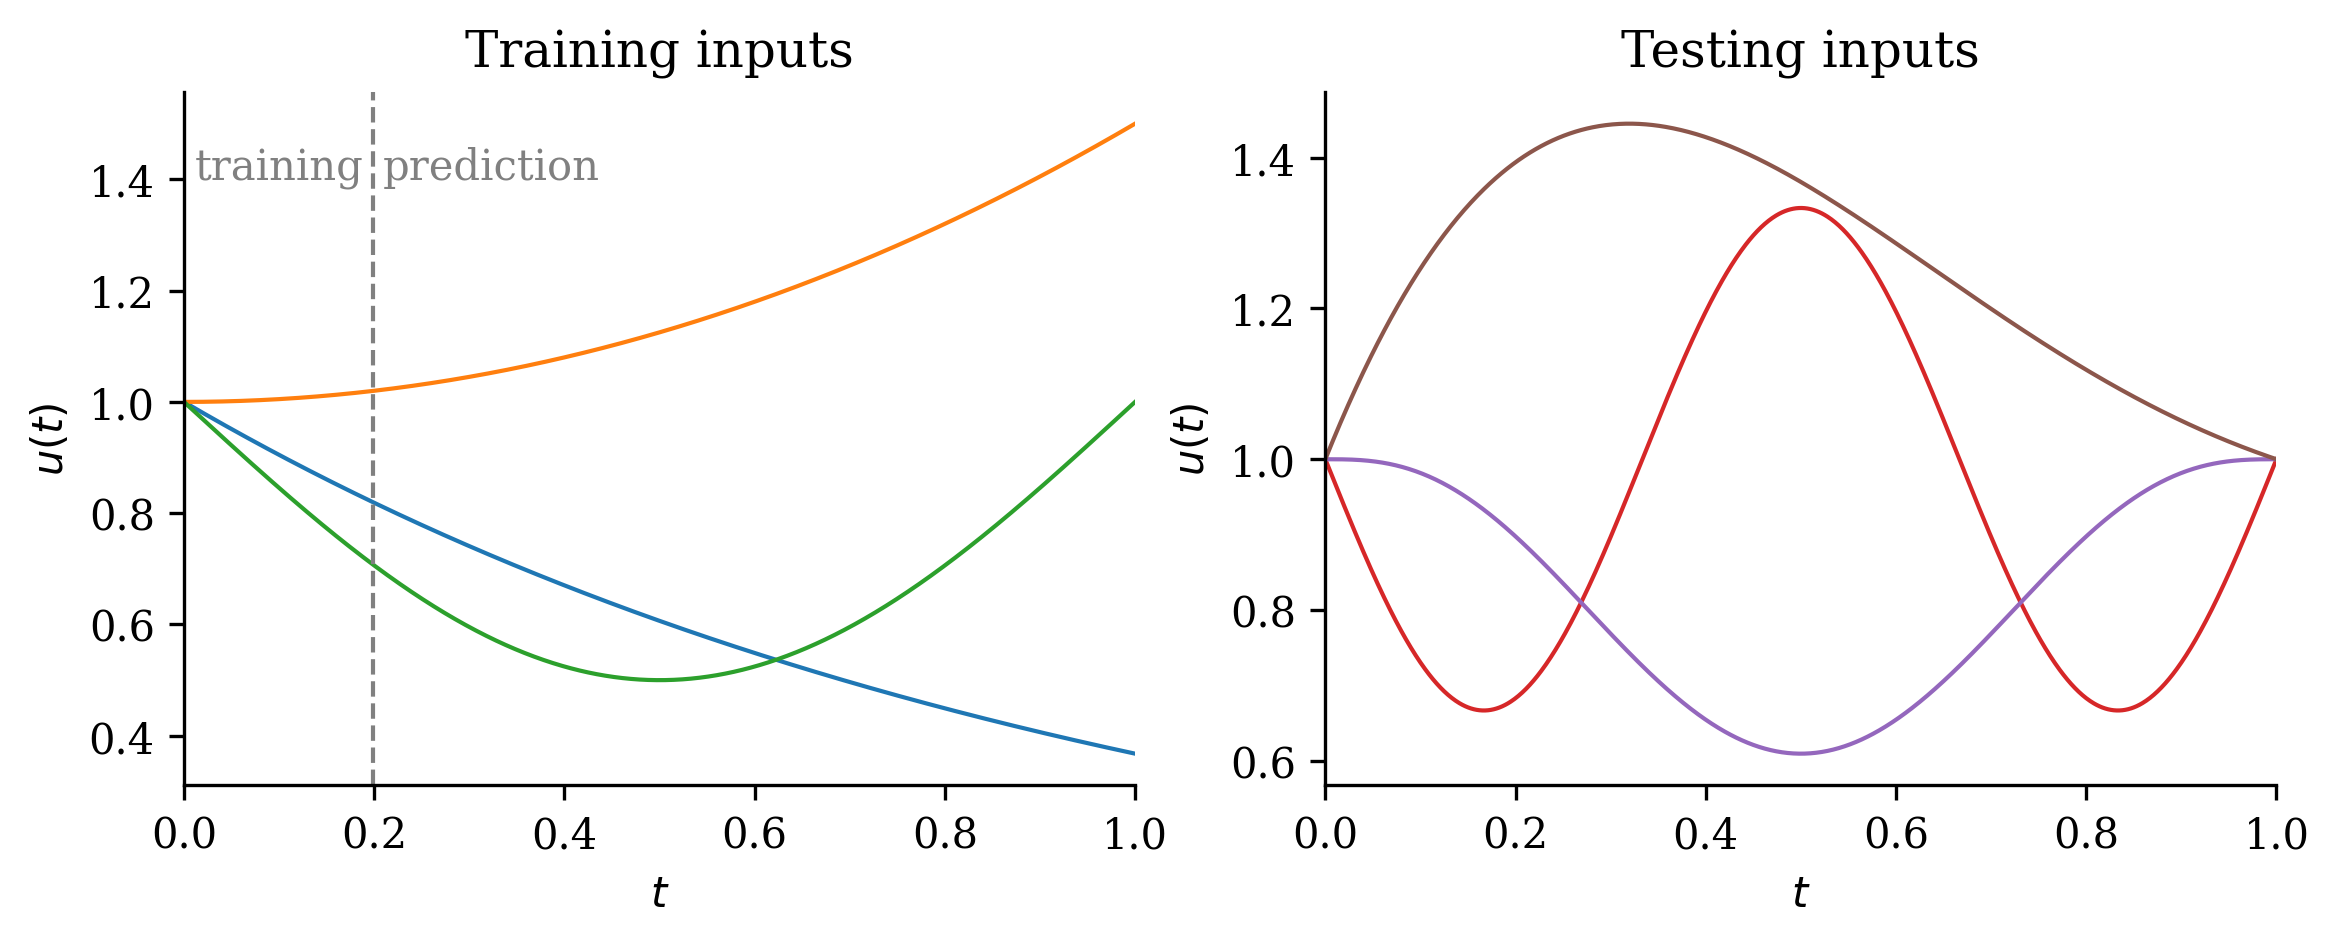

In [34]:
# Visualize the input functions.
fig, [ax1, ax2] = plt.subplots(1, 2, sharex=True)
c = 0
for input_func in training_inputs:
    ax1.plot(t_all, input_func(t_all)[0], color=f"C{c}", lw=1)
    c += 1
for input_func in testing_inputs:
    ax2.plot(t_all, input_func(t_all)[0], color=f"C{c}", lw=1)
    c += 1

ax1.set_title("Training inputs")
ax2.set_title("Testing inputs")
# ax1.axvline(t[-1], color="k", lw=1)
ax1.axvline(t[-1], color="gray", linewidth=1, linestyle="--")
ax1.text(t[-1] - 10 * dt, 1.4, "training", ha="right", color="gray")
ax1.text(t[-1] + 10 * dt, 1.4, "prediction", ha="left", color="gray")
for ax in (ax1, ax2):
    ax.set_xlim(t_all[0], t_all[-1])
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$u(t)$")
plt.show()

In [30]:
# Solve the full-order model for each training input and collect results.
Qs = []  # State snapshots.
Us = []  # Corresponding inputs.

for u in training_inputs:
    Qs.append(full_order_solve(t, u))
    Us.append(u(t))

In [31]:
rom = opinf.ROM(
    # basis=opinf.basis.PODBasis(residual_energy=1e-6),
    basis=opinf.basis.PODBasis(residual_energy=1e-8),
    ddt_estimator=opinf.ddt.UniformFiniteDifferencer(t, "ord6"),
    model=opinf.models.ContinuousModel("AB"),
)

with opinf.utils.TimedBlock("Fitting OpInf ROM"):
    rom.fit(Qs, inputs=Us)

rom_intrusive = opinf.ROM(
    basis=rom.basis,
    model=fom.galerkin(rom.basis.entries),
)

Fitting OpInf ROM...done in 2.98 s.


Test input function 1
Full-order solve...done in 4.38 s.
Reduced-order solve (OpInf)...done in 0.07 s.


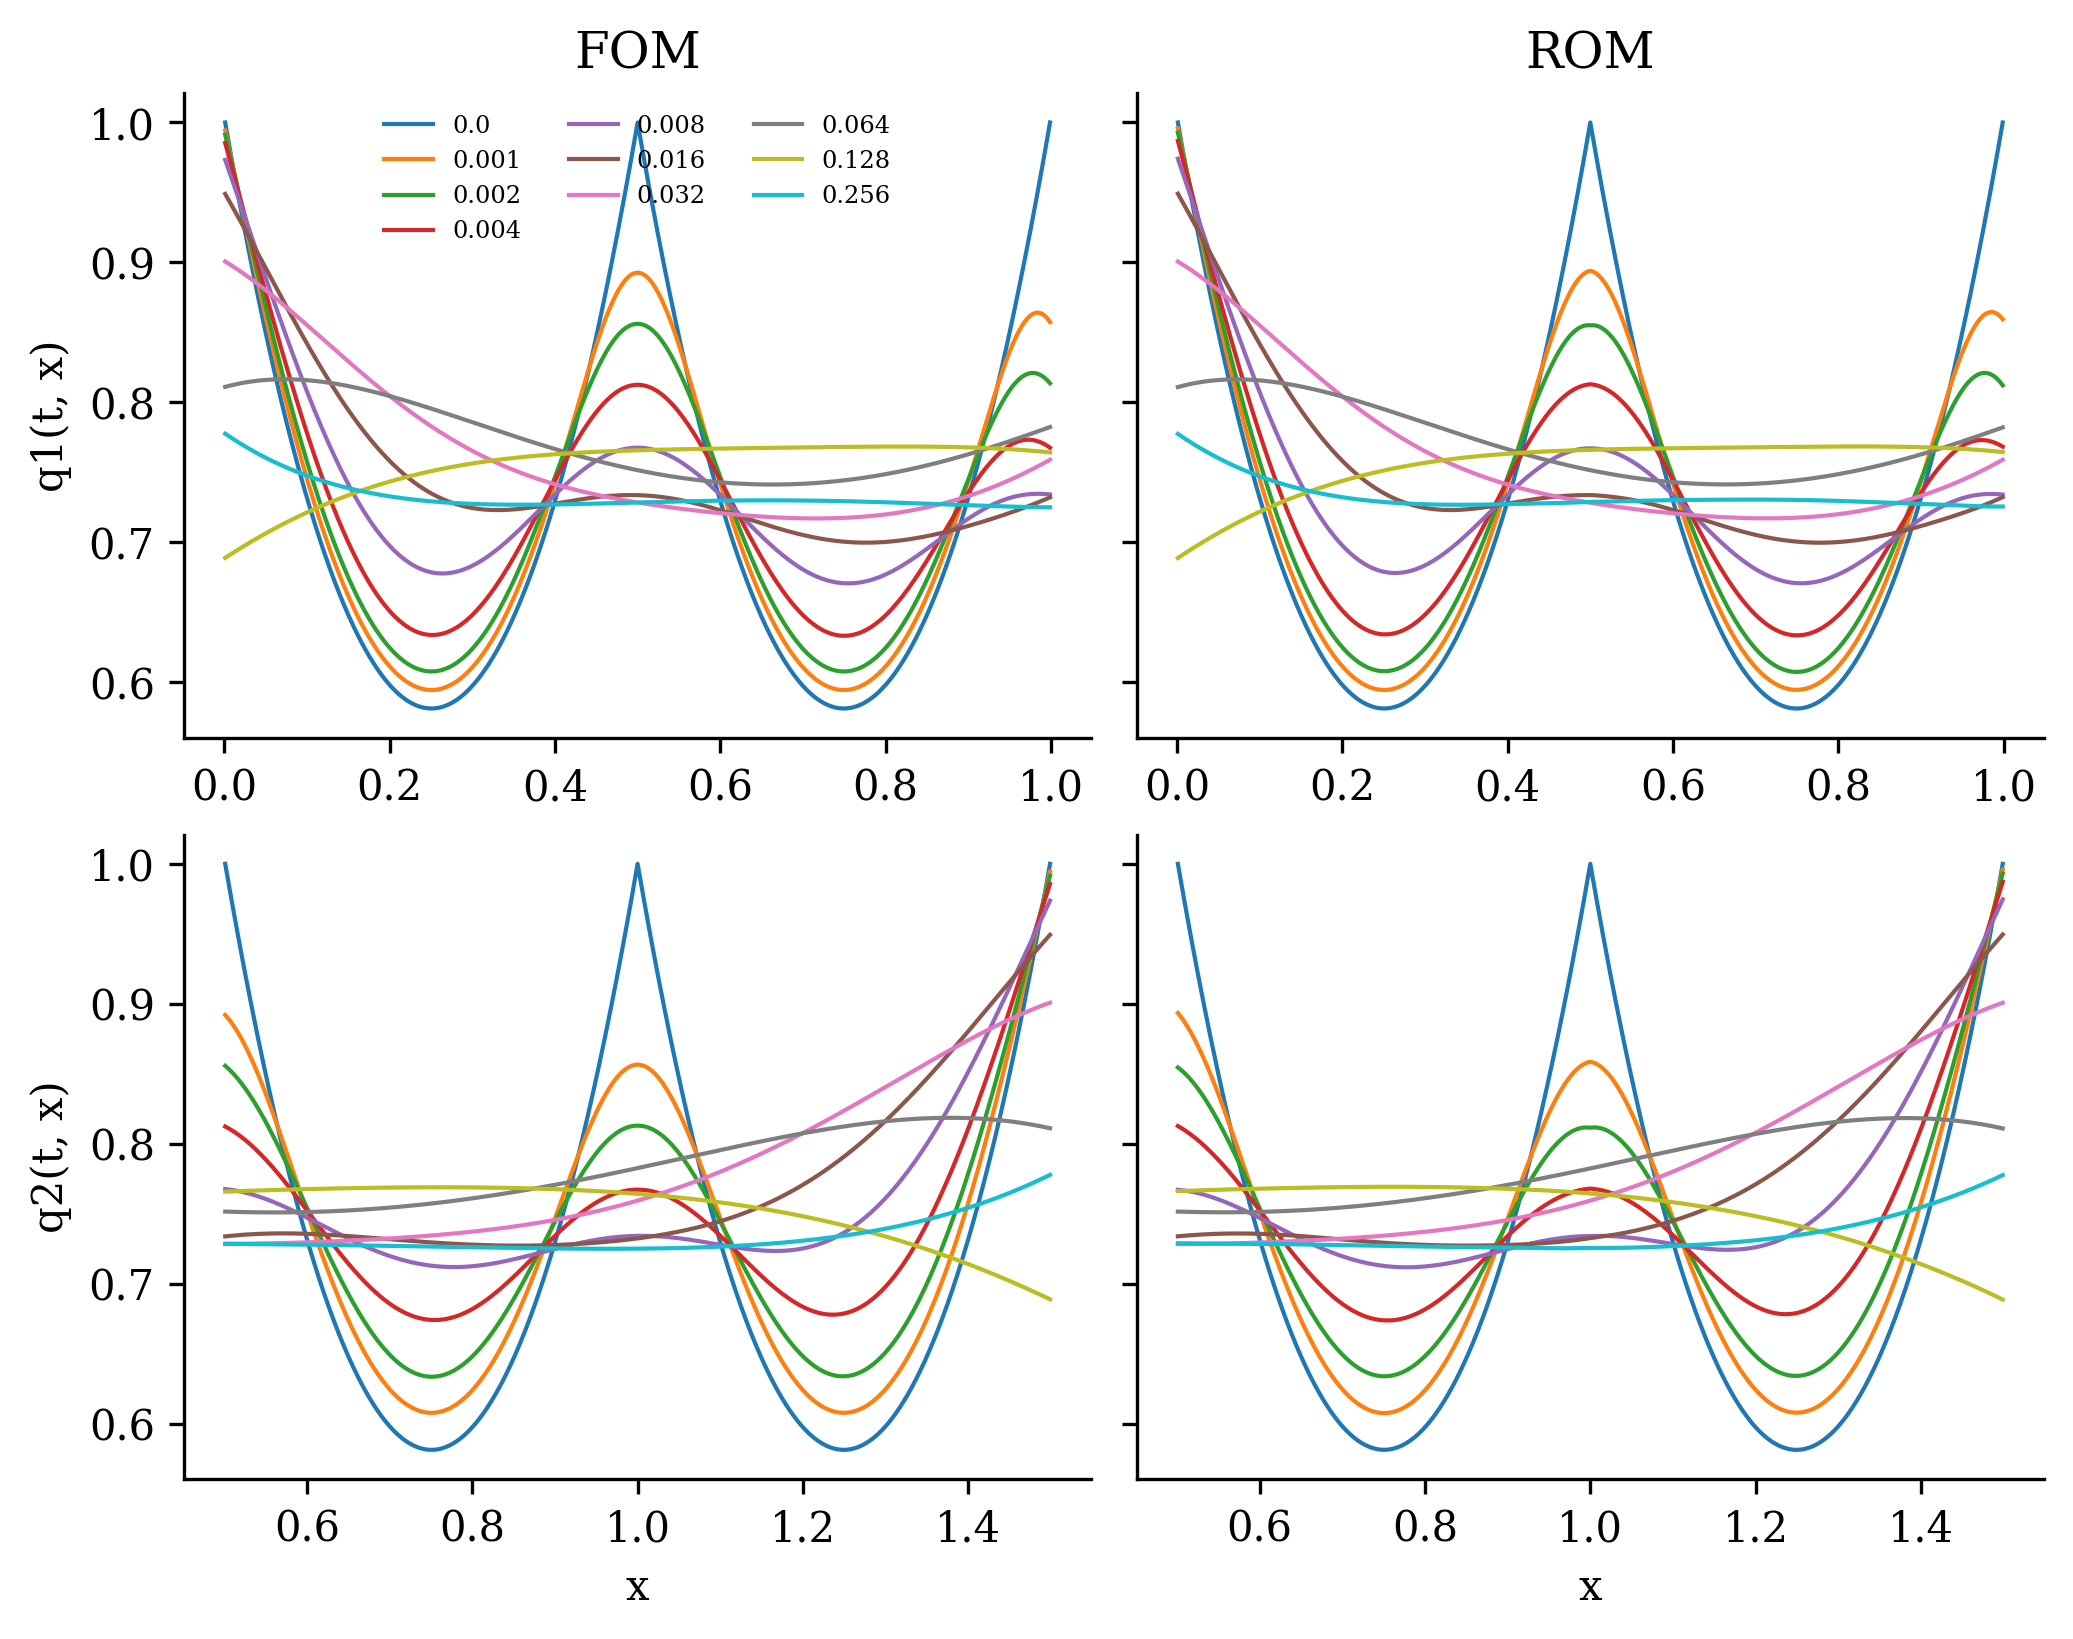

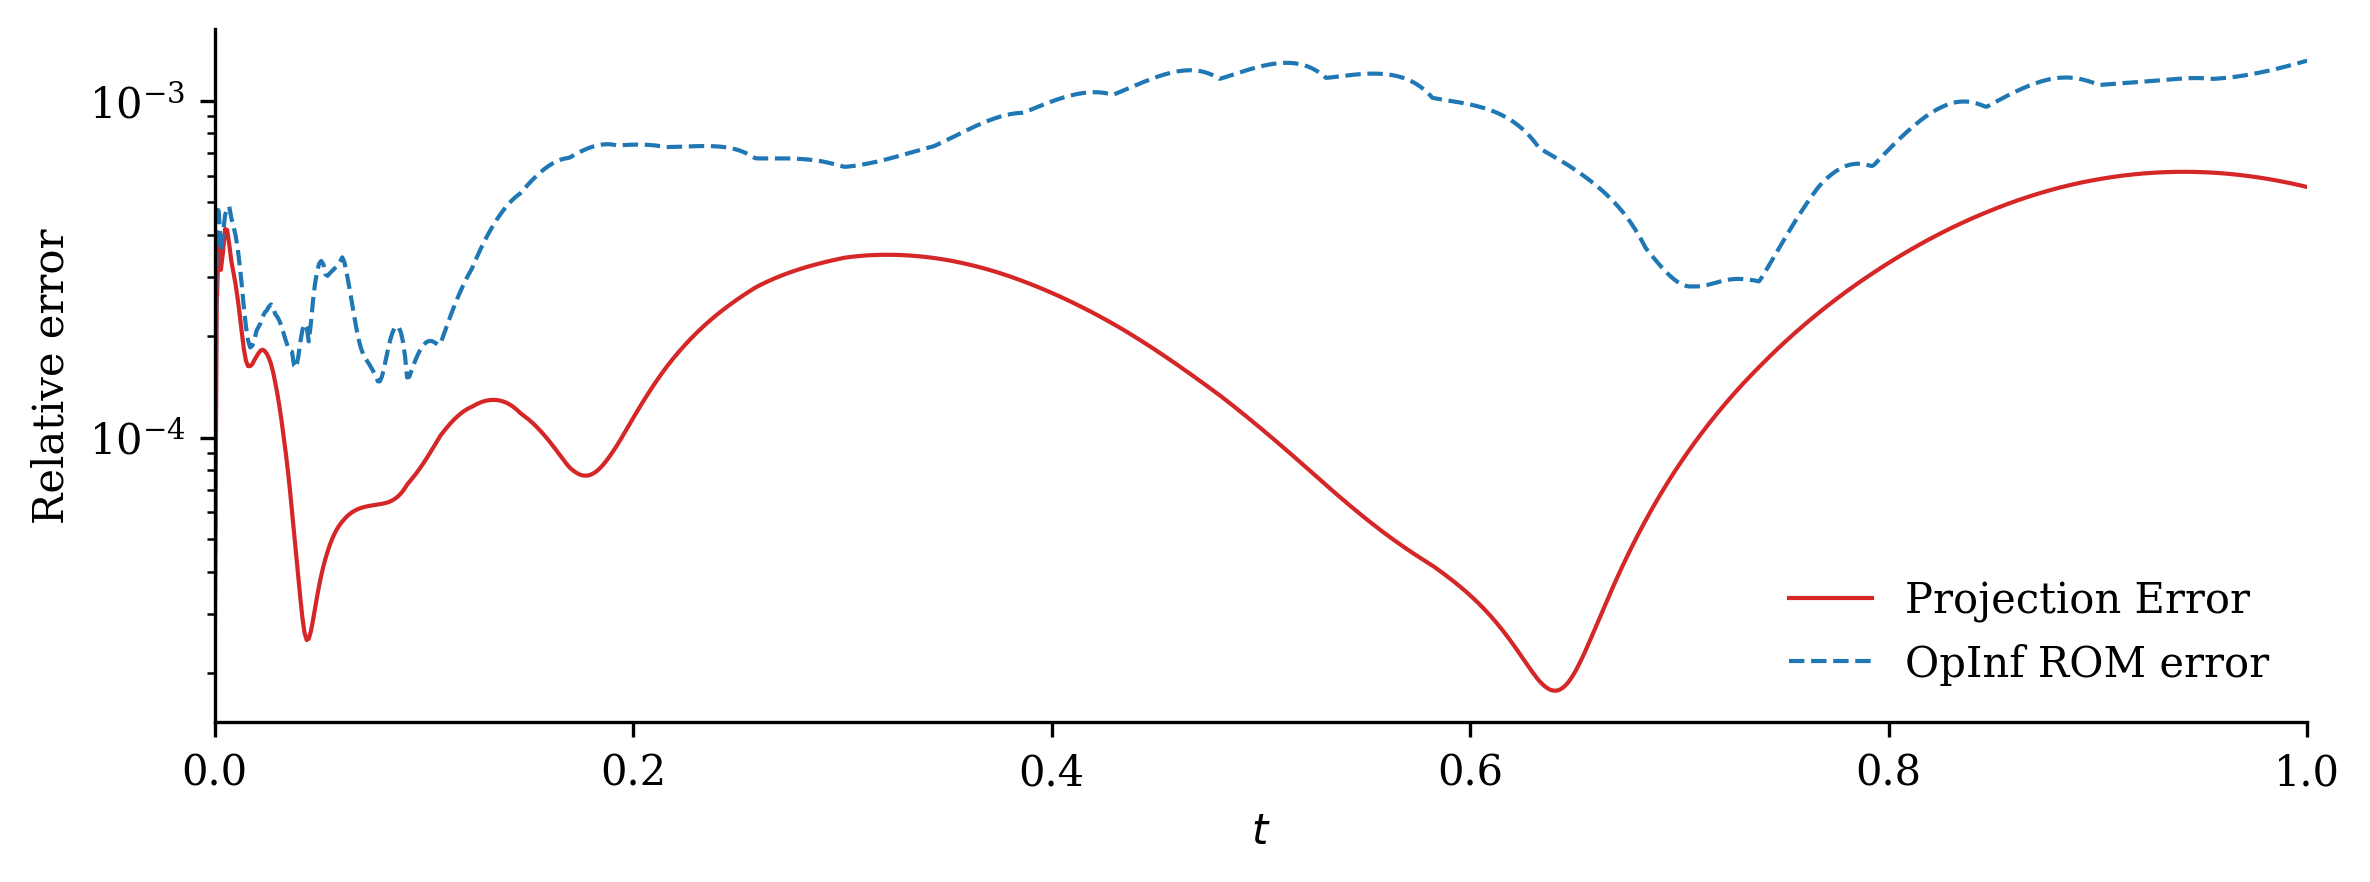

Test input function 2
Full-order solve...done in 6.22 s.
Reduced-order solve (OpInf)...done in 0.08 s.


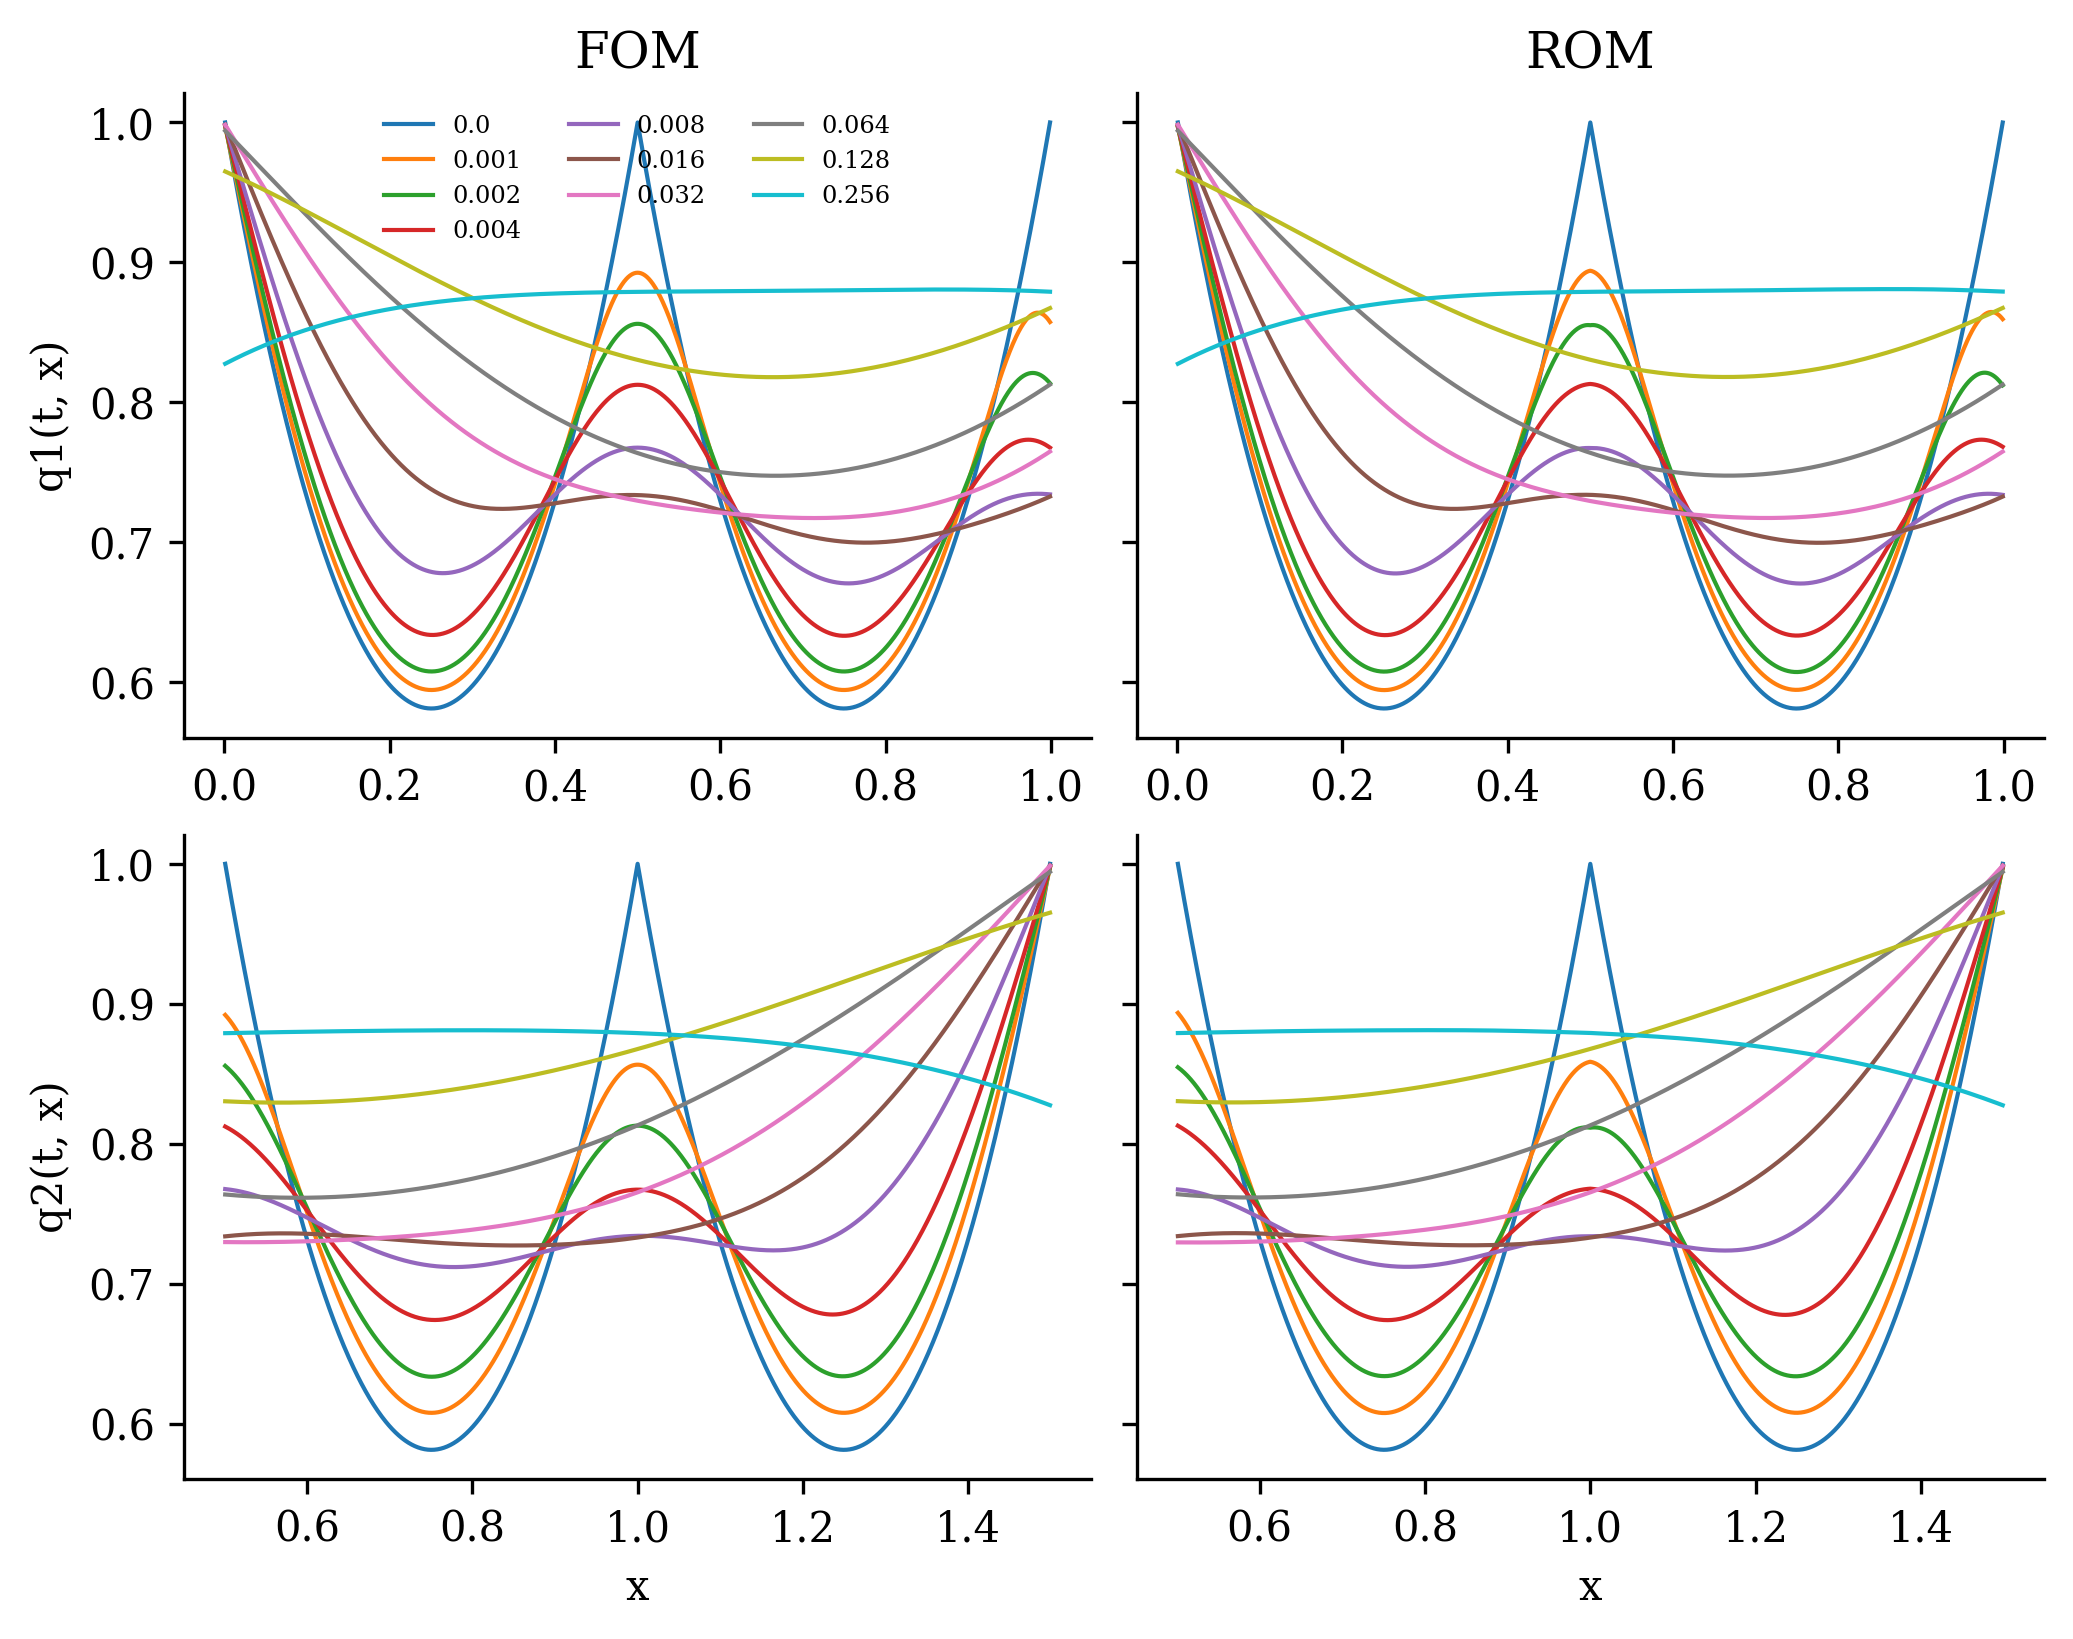

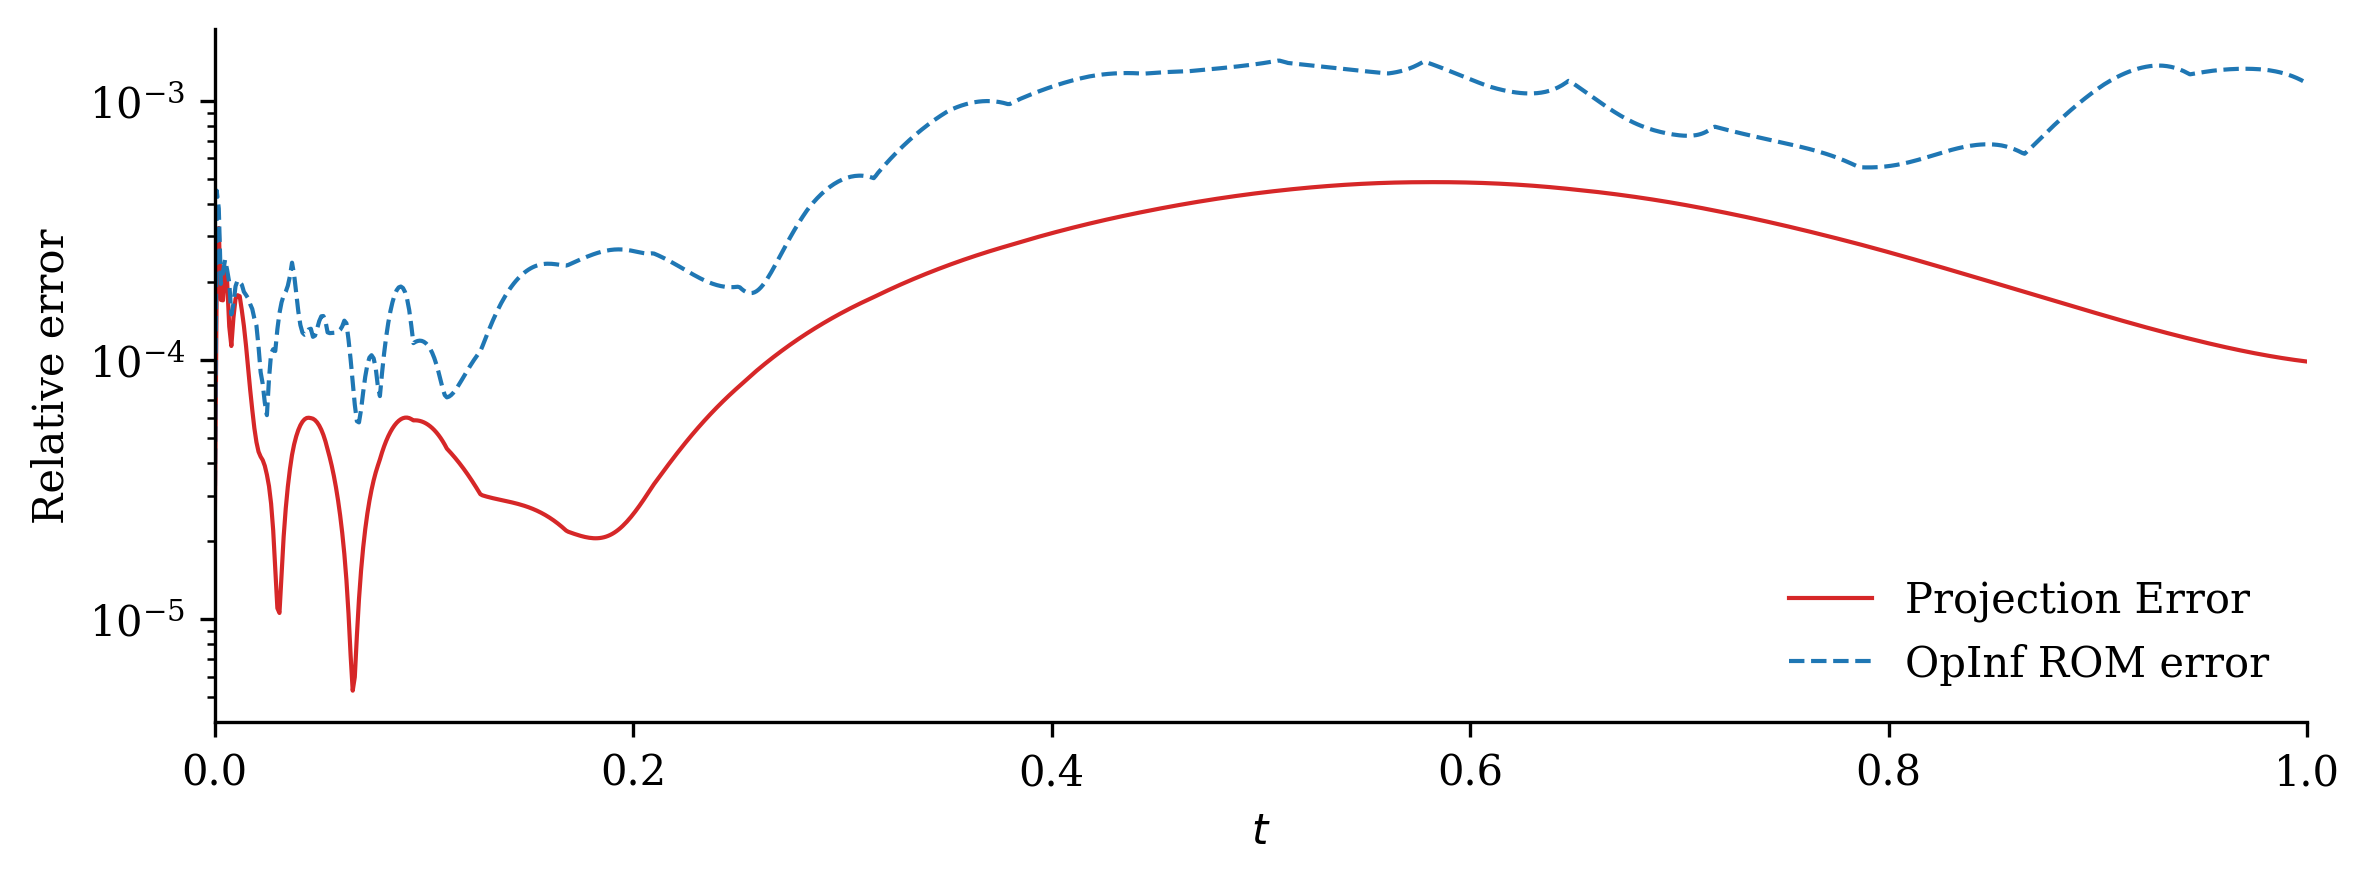

Test input function 3
Full-order solve...done in 3.76 s.
Reduced-order solve (OpInf)...done in 0.06 s.


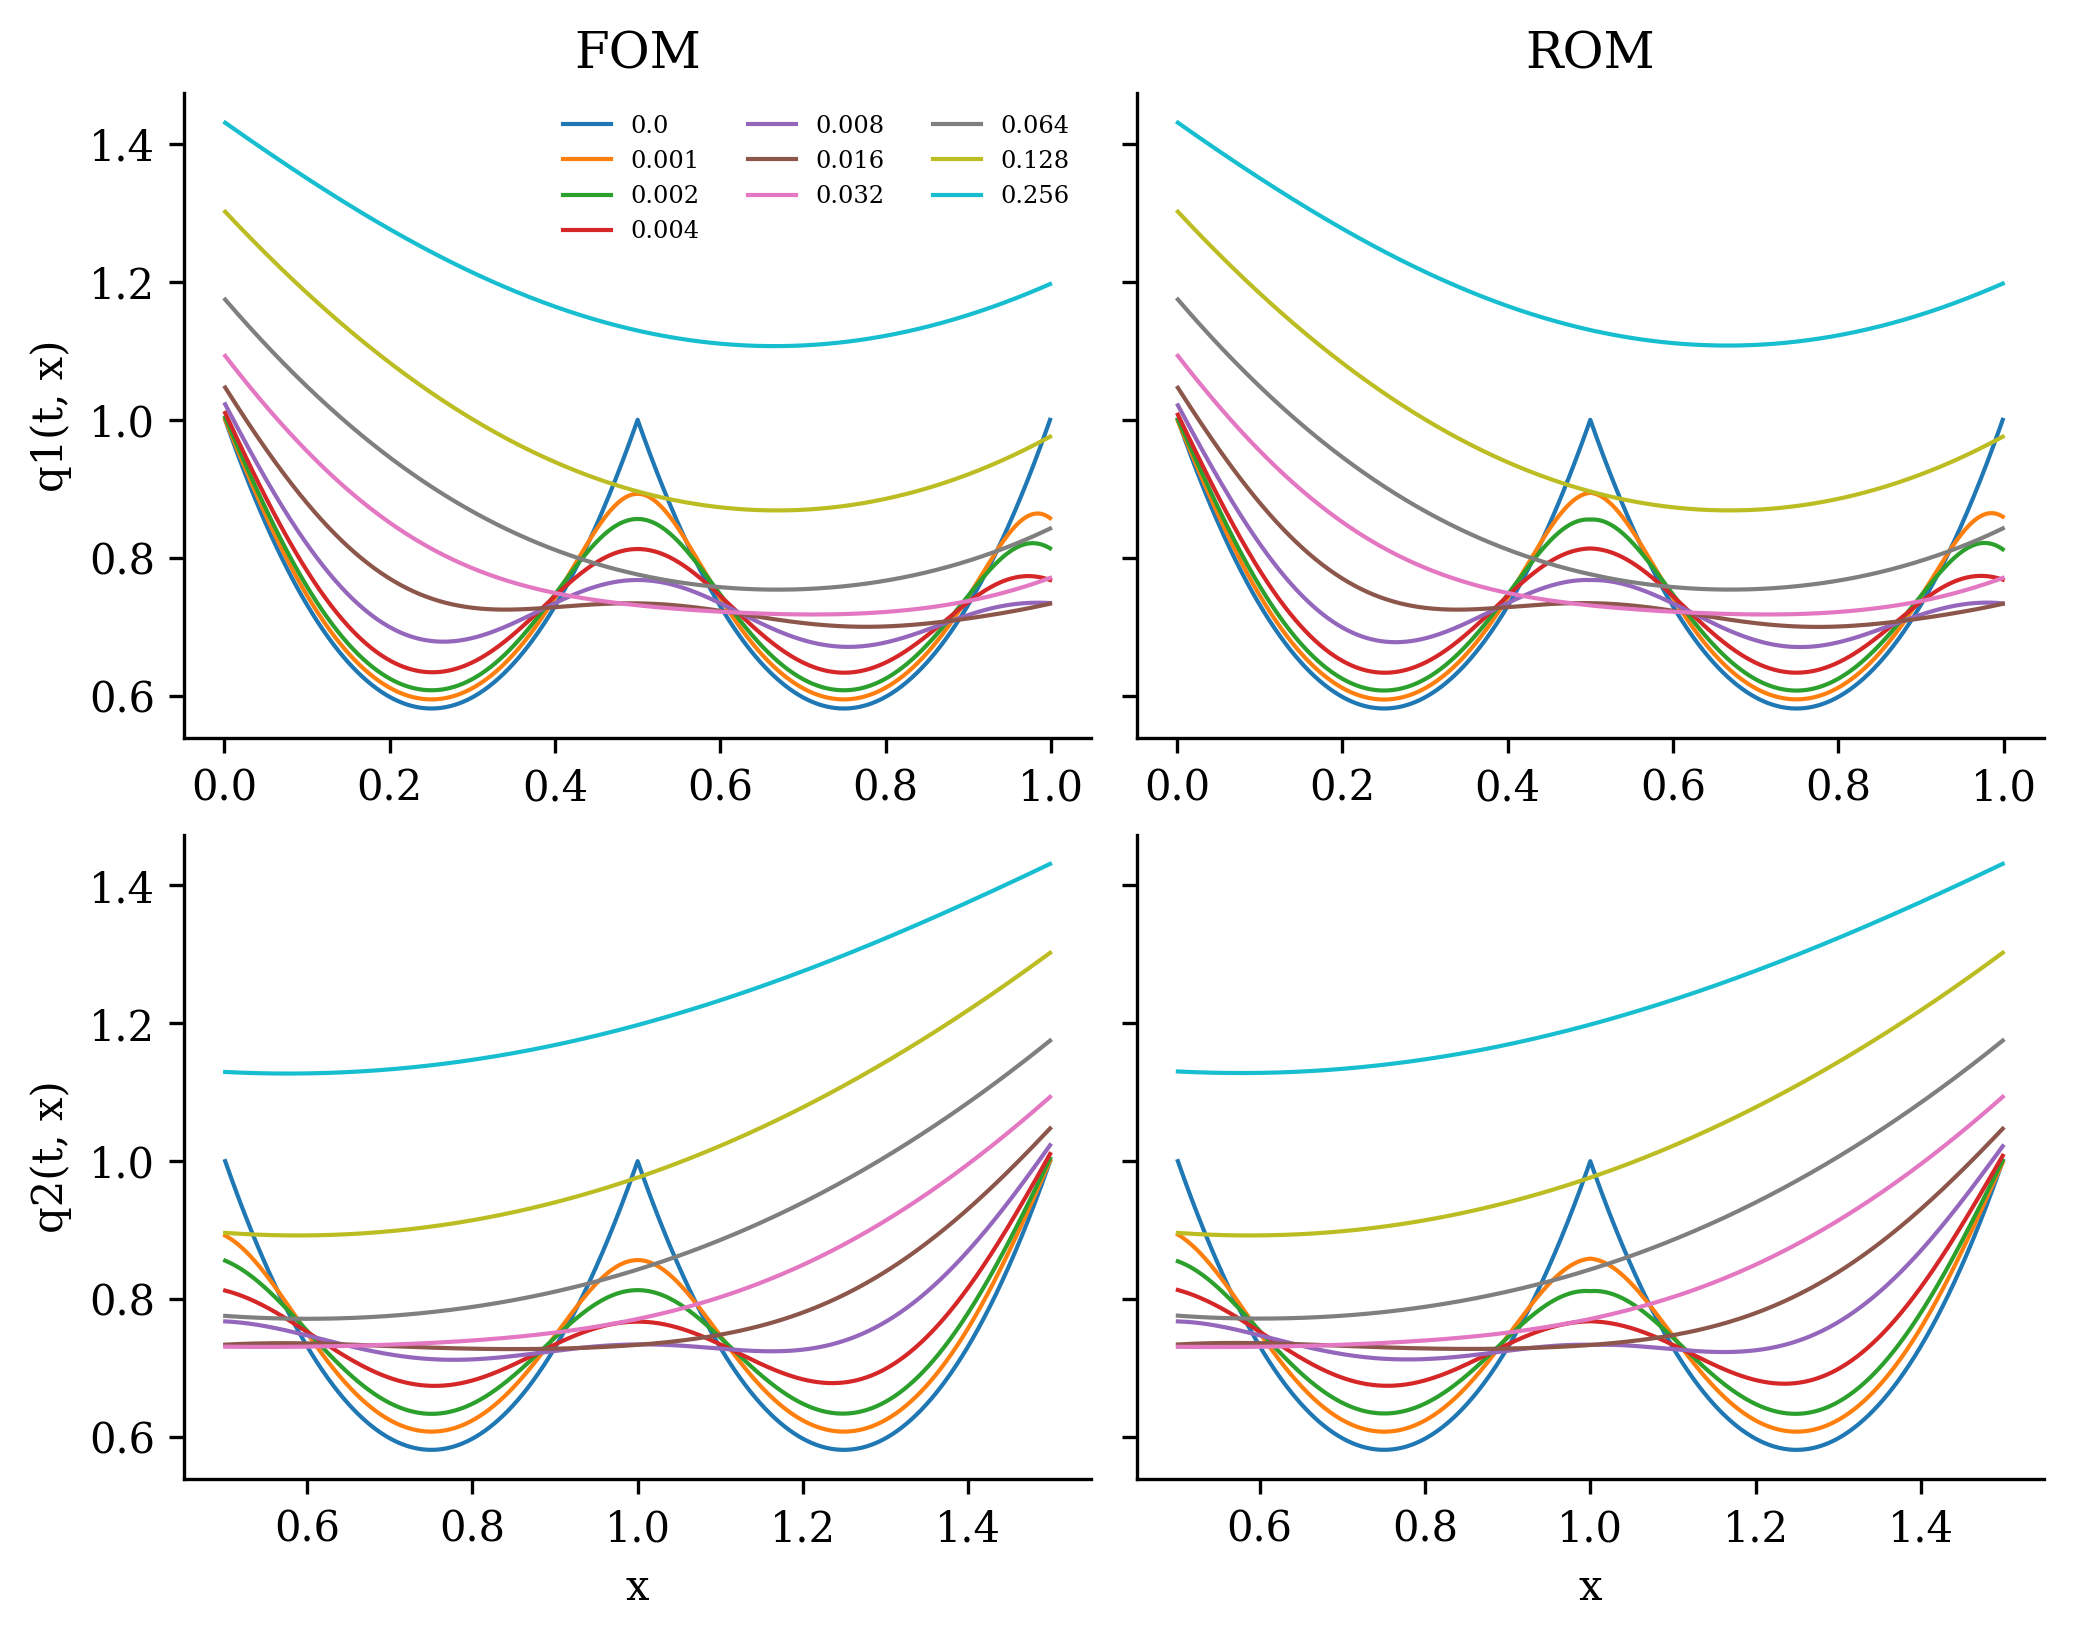

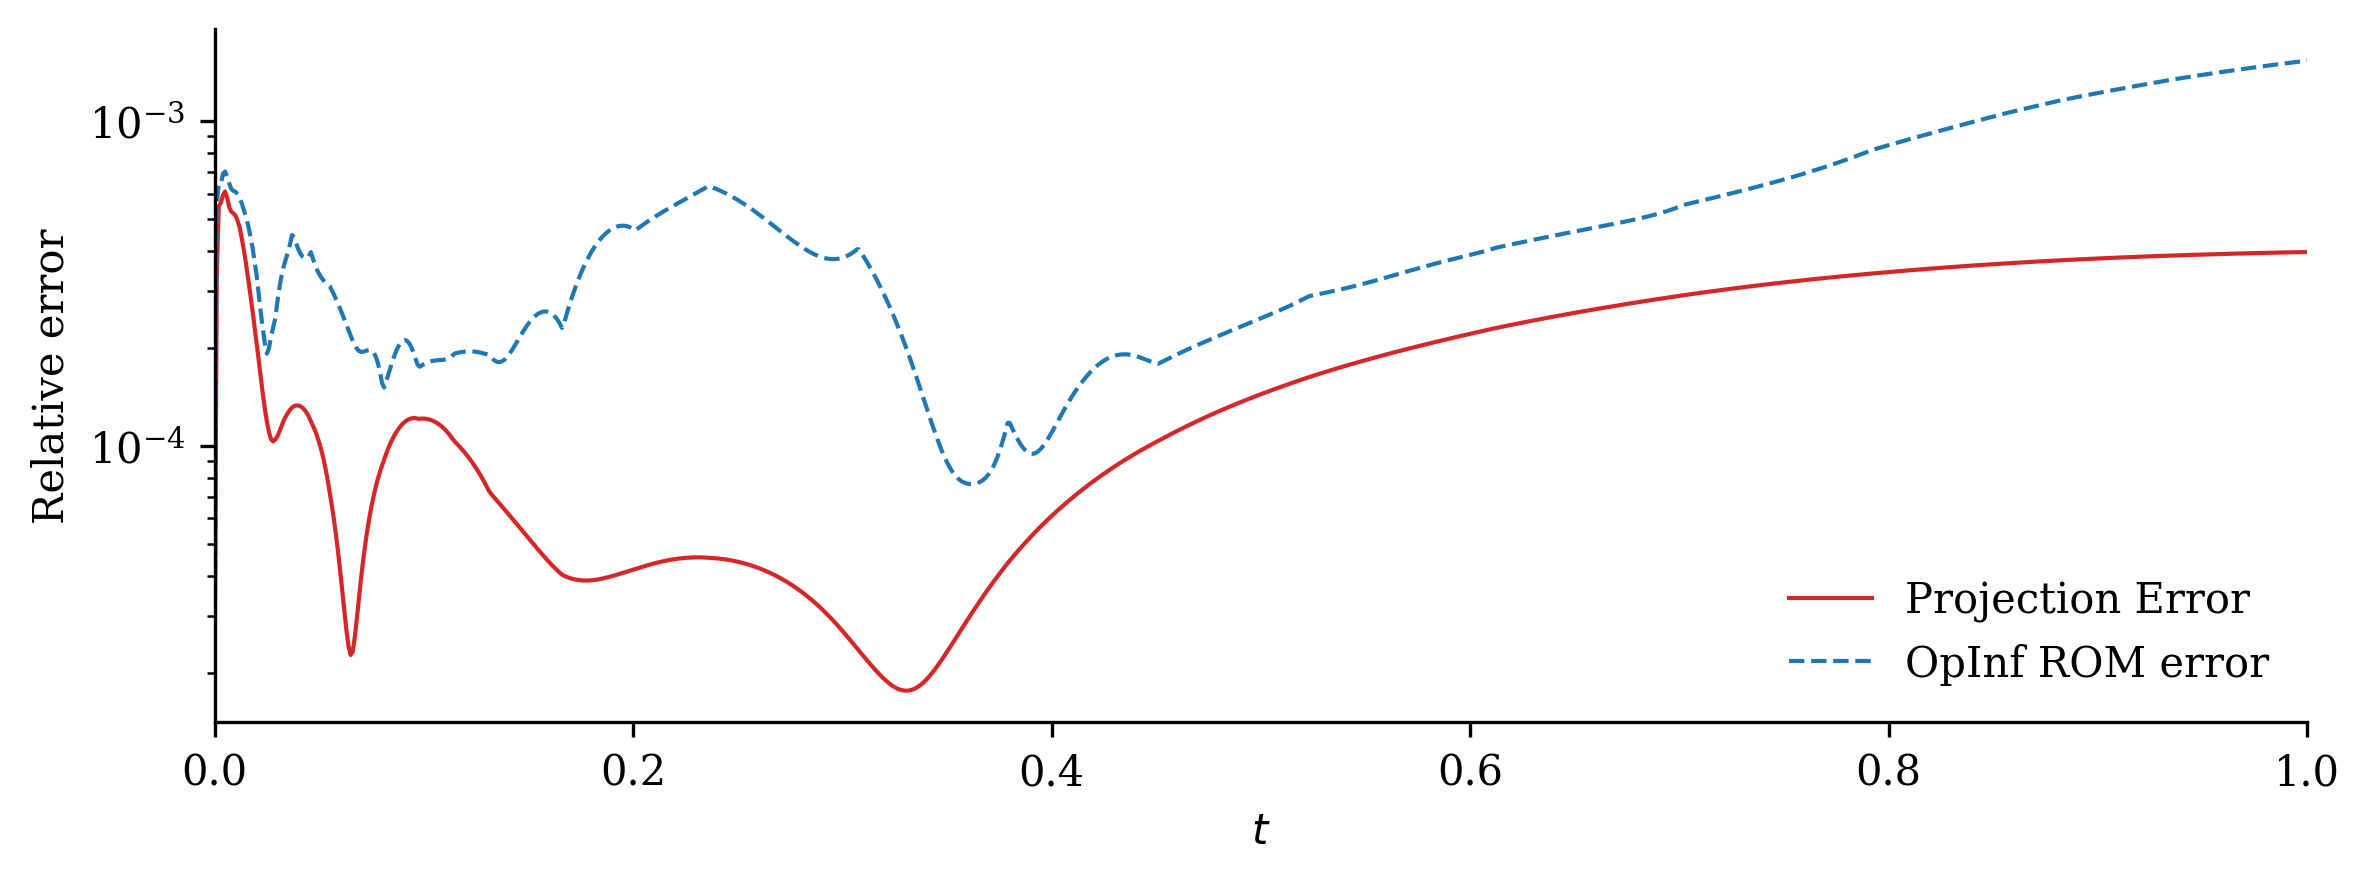

In [ ]:
for i, u in enumerate(testing_inputs):
    print(f"Test input function {i+1:d}")

    with opinf.utils.TimedBlock("Full-order solve"):
        Q_FOM = full_order_solve(t_all, u)

    with opinf.utils.TimedBlock("Reduced-order solve (OpInf)"):
        Q_ROM = rom.predict(q0, t_all, u, method="BDF")

    # with opinf.utils.TimedBlock("Reduced-order solve (intrusive)"):
    #     Q_ROM_intrusive = rom_intrusive.predict(q0, t_all, u, method="BDF")

    # plot_two_datasets(
    #     Q_ROM,
    #     Q_FOM,
    #     u,
    #     "Reduced-order model solution (OpInf)",
    #     "Full-order model solution",
    # )
    fig, ax = plt.subplots(2, 2, sharex="row", sharey=True, figsize=(8, 6))

    for k in [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]:
        y1 = np.concatenate([
            # [training_input(k)[0]],
            Q_FOM[:n, k],
            # [Q_FOM[n+n//2, k]],
            ])
        y1rom = np.concatenate([
            # [training_input(k)[0]],
            Q_ROM[:n, k],
            # [Q_FOM[n+n//2, k]],
            ])
        y2 = np.concatenate([
            # [Q_FOM[n//2, k]],
            Q_FOM[n:, k],
            # [training_input(k)[1]],
            ])
        y2rom = np.concatenate([
            # [Q_FOM[n//2, k]],
            Q_ROM[n:, k],
            # [training_input(k)[1]],
            ])

        l = ax[0, 0].plot(x, y1, label=t_all[k], linewidth=1)
        ax[0, 1].plot(x, y1rom, label=t_all[k], linewidth=1, color=l[-1].get_color())

        l = ax[1, 0].plot(x + x[n//2], y2, label=t_all[k], linewidth=1)
        ax[1, 1].plot(x + x[n//2], y2rom, label=t_all[k], linewidth=1, color=l[-1].get_color())

    ax[0, 0].set_title("FOM")
    ax[0, 1].set_title("ROM")

    ax[1, 0].set_xlabel("x")
    ax[1, 1].set_xlabel("x")

    ax[0, 0].set_ylabel("q1(t, x)")
    ax[1, 0].set_ylabel("q2(t, x)")

    ax[0, 0].legend(fontsize="xx-small", ncol=3)

    fig.subplots_adjust(wspace=0.05, hspace=0.15)

    plt.show()

    plot_errors_over_time(
        Q_FOM,
        rom.basis,
        Q_ROM,
        "OpInf ROM error",
        # Q_ROM_intrusive,
        # "Intrusive ROM error",
    )